# Feature Engineering - Daily Revenue Forecasting

## Mục tiêu

- Tạo bộ feature phục vụ bài toán dự báo doanh thu theo ngày.
- Đưa các bảng nguồn khác grain về cùng grain daily trước khi merge.
- Kiểm soát leakage: chỉ dùng feature known-now hoặc feature đã lag/rolling từ quá khứ.
- Sàng lọc feature theo chất lượng, độ liên quan với target, trùng lặp thông tin, độ ổn định theo thời gian và giá trị khi validation theo thời gian.
- Xuất các bảng CSV cuối cùng để chuẩn bị cho bước huấn luyện model.

## Đầu vào

- `data/sales.csv`: bảng target daily gồm `Date`, `Revenue`, `COGS`.
- `data/sample_submission.csv`: khung ngày cần dự báo.
- `data/web_traffic.csv`: tín hiệu traffic, cần aggregate về daily.
- `data/orders.csv`: tín hiệu đơn hàng, chỉ dùng dạng lag/rolling để tránh leakage.
- `data/promotions.csv`: lịch khuyến mãi, có thể dùng same-day nếu biết trước ngày dự báo.
- `data/order_items.csv`: bảng chi tiết đơn hàng, chỉ dùng nếu cần aggregate product/order mix.
- Không lấy output của các report ngày khác làm đầu vào feature engineering.

## Đầu ra chính

- `candidate_features_daily_all_candidates.csv`: toàn bộ feature candidates sau Phase 3.
- `modeling_dataset_final.csv`: bảng daily cuối cho modeling, gồm `Date`, target columns và 21 selected features.
- `final_feature_list.csv`: danh sách 21 feature được giữ lại cho modeling.
- `feature_selection_scores.csv`: bảng audit đầy đủ cho toàn bộ 190 candidate features.
- `final_feature_scores.csv`: bảng audit điểm cho đúng 21 selected features.
- `modeling_feature_metadata.csv`: metadata gọn của 21 feature cho notebook modeling.
- `feature_selection_summary.csv`: bảng audit số lượng feature qua từng bước.

## Quy trình

- Phase 0: Setup môi trường, đường dẫn và ngưỡng cấu hình.
- Phase 1: Load raw data và kiểm tra schema/grain ban đầu.
- Phase 2: Clean nhẹ đủ cho feature engineering.
- Phase 3.1: Tạo target daily spine và target lag/rolling features.
- Phase 3.2: Aggregate các bảng nguồn về grain daily.
- Phase 3.3: Merge các feature daily thành candidate table.
- Phase 4.1: Quality filter.
- Phase 4.2: Univariate relevance bằng Spearman.
- Phase 4.3: Redundancy filter và family cap.
- Phase 4.4: Temporal stability check.
- Phase 4.5: Time-aware wrapper để hỗ trợ chọn feature.
- Phase 5: Final audit và export output cho modeling.


# Phase 0 - Setup

- Mục tiêu: chuẩn bị môi trường chạy notebook trước khi xử lý dữ liệu.
- Import thư viện cần dùng cho feature engineering.
- Xác định `PROJECT_ROOT`, thư mục input `data/`, và thư mục output `report_5_6_2026/fe_outputs/`.
- Tạo sẵn thư mục lưu bảng CSV và hình ảnh.
- Khai báo các ngưỡng sàng lọc feature để các phase sau dùng thống nhất.


In [248]:
# Phase 0 - Setup môi trường và đường dẫn chung
from pathlib import Path
import sys
import re
from datetime import datetime
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root():
    """Tìm thư mục project chứa cả ds_utils.py và data/."""
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]

    # Một vài vị trí hay gặp khi chạy notebook trên máy local hoặc Google Drive.
    extra_candidates = [
        start / 'VinuniDatathon',
        Path('/content/drive/MyDrive/VinuniDatathon'),
        Path('B:/Dự án VSF/VinuniDatathon'),
    ]
    candidates.extend(extra_candidates)

    checked = []
    for candidate in candidates:
        candidate = candidate.resolve() if candidate.exists() else candidate
        roots_to_check = [candidate]
        if candidate.exists():
            roots_to_check.extend(candidate.parents)

        for root in roots_to_check:
            checked.append(str(root))
            if (root / 'ds_utils.py').exists() and (root / 'data').exists():
                return root

    preview = '\n'.join(dict.fromkeys(checked[-12:]))
    raise FileNotFoundError(
        'Không tìm thấy PROJECT_ROOT chứa cả ds_utils.py và data/.\n'
        'Hãy mở notebook từ thư mục VinuniDatathon hoặc sửa PROJECT_ROOT thủ công.\n'
        f'Các vị trí đã kiểm tra gần nhất:\n{preview}'
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import ds_utils as du

DATA_DIR = PROJECT_ROOT / 'data'
NOTEBOOK_DIR = PROJECT_ROOT / 'report_5_6_2026'
OUTPUT_DIR = NOTEBOOK_DIR / 'fe_outputs'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', palette='deep')

RANDOM_STATE = 42
DATE_COL = 'Date'
TARGET_COL = 'Revenue'
COGS_COL = 'COGS'
TARGET_COLS = [TARGET_COL, COGS_COL]
CV_FOLDS = 3
TOP_N_FEATURES = 25
MAX_MISSING_RATE = 0.3
MAX_ZERO_RATE = 0.95
MAX_ABS_CORR = 0.9
MIN_IMPORTANCE_SHARE = 0.01

# Ngưỡng dùng trong Phase 4; missing_pct đang tính theo %, còn correlation tính từ 0 đến 1.
MISSING_REVIEW_THRESHOLD = MAX_MISSING_RATE * 100
RELEVANCE_DROP_THRESHOLD = 0.1
RELEVANCE_REVIEW_THRESHOLD = 0.3
HIGH_CORR_THRESHOLD = MAX_ABS_CORR
FAMILY_CAP = 4
RUN_OPTIONAL_WRAPPER = True


def save_df(df, filename, index=False):
    path = TABLE_DIR / filename
    df.to_csv(path, index=index)
    print(f'Saved: {path}')
    return path


def save_fig(fig_or_filename, filename=None, dpi=150):
    """Lưu biểu đồ; hỗ trợ cả save_fig(fig, filename) và save_fig(filename)."""
    if filename is None:
        fig = plt.gcf()
        filename = fig_or_filename
    else:
        fig = fig_or_filename

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved: {path}')
    return path


def slugify(name):
    return re.sub(r'[^0-9a-zA-Z_]+', '_', str(name).strip()).strip('_').lower()


def assert_unique_key(df, key_cols, label):
    dup_count = df.duplicated(key_cols).sum()
    print(f'{label}: duplicate theo {key_cols} = {dup_count:,}')
    if dup_count > 0:
        display(df.loc[df.duplicated(key_cols, keep=False), key_cols].head(10))
    return dup_count


def weighted_mean(values, weights=None, weight_col=None):
    """Tính trung bình có trọng số; nhận series hoặc DataFrame groupby."""
    if isinstance(values, pd.DataFrame):
        df = values
        value_col = weights
        if value_col not in df.columns or weight_col not in df.columns:
            return np.nan
        values = df[value_col]
        weights = df[weight_col]

    values = pd.Series(values, dtype='float64')
    weights = pd.Series(weights, dtype='float64')
    valid = values.notna() & weights.notna() & (weights != 0)
    if valid.sum() == 0:
        return np.nan
    return np.average(values[valid], weights=weights[valid])

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'ds_utils.py exists = {(PROJECT_ROOT / "ds_utils.py").exists()}')
print(f'data dir exists = {(PROJECT_ROOT / "data").exists()}')
print(f'Output tables: {TABLE_DIR}')
print(f'Output figures: {FIGURE_DIR}')
print('Setup completed at', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))


PROJECT_ROOT = B:\Dự án VSF\VinuniDatathon
ds_utils.py exists = True
data dir exists = True
Output tables: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables
Output figures: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures
Setup completed at 2026-06-08 15:03:04


## Tổng quan quy trình

- Mục tiêu: cho người đọc thấy toàn bộ pipeline feature engineering trước khi đi vào code.
- Mỗi phase tạo ra một nhóm output rõ ràng để phase sau sử dụng.
- Các phase được chạy theo thứ tự: load dữ liệu, clean nhẹ, tạo feature, sàng lọc feature, rồi xuất dữ liệu cuối.
- Bảng dưới đây là checklist luồng xử lý, không phải kết quả modeling.


In [249]:
pipeline_steps = pd.DataFrame([
    {'phase': 'Phase 0', 'nhiem_vu': 'Setup', 'muc_tieu': 'Chuẩn bị thư viện, đường dẫn, thư mục output và ngưỡng cấu hình.'},
    {'phase': 'Phase 1', 'nhiem_vu': 'Load raw data', 'muc_tieu': 'Nạp dữ liệu gốc từ thư mục data và kiểm tra schema/grain ban đầu.'},
    {'phase': 'Phase 2', 'nhiem_vu': 'Light data cleaning', 'muc_tieu': 'Clean tối thiểu để aggregate, join và tạo feature không sai logic.'},
    {'phase': 'Phase 3.1', 'nhiem_vu': 'Target lag/rolling', 'muc_tieu': 'Tạo target daily spine và feature lịch sử đã shift để tránh leakage.'},
    {'phase': 'Phase 3.2', 'nhiem_vu': 'Aggregate source tables', 'muc_tieu': 'Đưa web traffic, orders, promotions và calendar về grain daily.'},
    {'phase': 'Phase 3.3', 'nhiem_vu': 'Merge daily features', 'muc_tieu': 'Merge các bảng daily vào target spine và kiểm tra không nhân dòng.'},
    {'phase': 'Phase 4.1', 'nhiem_vu': 'Quality filter', 'muc_tieu': 'Đánh giá missing, variance, nunique và loại feature chất lượng kém.'},
    {'phase': 'Phase 4.2', 'nhiem_vu': 'Univariate relevance', 'muc_tieu': 'Đo quan hệ Spearman giữa feature và target để lọc nhiễu ban đầu.'},
    {'phase': 'Phase 4.3', 'nhiem_vu': 'Redundancy & family cap', 'muc_tieu': 'Giảm feature trùng thông tin và giới hạn số biến trong cùng family.'},
    {'phase': 'Phase 4.4', 'nhiem_vu': 'Temporal stability', 'muc_tieu': 'Kiểm tra signal feature-target có ổn định qua thời gian không.'},
    {'phase': 'Phase 4.5', 'nhiem_vu': 'Time-aware wrapper', 'muc_tieu': 'Kiểm tra feature group/family có giúp giảm WAPE khi validation theo thời gian không.'},
    {'phase': 'Phase 5', 'nhiem_vu': 'Final audit & export', 'muc_tieu': 'Xuất feature decision, selected features và bảng daily cuối cho modeling.'},
])

du.show(pipeline_steps, title='Tổng quan quy trình Feature Engineering')




Tổng quan quy trình Feature Engineering


,phase,nhiem_vu,muc_tieu
0,Phase 0,Setup,"Chuẩn bị thư viện, đường dẫn, thư mục output v..."
1,Phase 1,Load raw data,Nạp dữ liệu gốc từ thư mục data và kiểm tra sc...
2,Phase 2,Light data cleaning,"Clean tối thiểu để aggregate, join và tạo feat..."
3,Phase 3.1,Target lag/rolling,Tạo target daily spine và feature lịch sử đã s...
4,Phase 3.2,Aggregate source tables,"Đưa web traffic, orders, promotions và calenda..."
5,Phase 3.3,Merge daily features,Merge các bảng daily vào target spine và kiểm ...
6,Phase 4.1,Quality filter,"Đánh giá missing, variance, nunique và loại fe..."
7,Phase 4.2,Univariate relevance,Đo quan hệ Spearman giữa feature và target để ...
8,Phase 4.3,Redundancy & family cap,Giảm feature trùng thông tin và giới hạn số bi...
9,Phase 4.4,Temporal stability,Kiểm tra signal feature-target có ổn định qua ...


# Phase 1 - Load Raw Data

- Mục tiêu: nạp các bảng raw từ thư mục `data/` vào notebook.
- Kiểm tra nhanh số dòng, số cột, cột ngày và grain kỳ vọng của từng bảng.
- Ghi lại vai trò của từng bảng trong feature engineering.
- Chưa join bảng và chưa tạo feature ở phase này.
- Output chính: `load_summary.csv`.


In [250]:
TABLE_FILES = {
    'sales': 'sales.csv',
    'sample_submission': 'sample_submission.csv',
    'web_traffic': 'web_traffic.csv',
    'orders': 'orders.csv',
    'promotions': 'promotions.csv',
    'order_items': 'order_items.csv',
}

TABLE_EXPECTATIONS = {
    'sales': {'date_col': 'Date', 'grain_expected': 'daily', 'note': 'target table'},
    'sample_submission': {'date_col': 'Date', 'grain_expected': 'forecast daily', 'note': 'forecast frame'},
    'web_traffic': {'date_col': 'date', 'grain_expected': 'date x traffic_source', 'note': 'cần aggregate'},
    'orders': {'date_col': 'order_date', 'grain_expected': '1 order/row', 'note': 'cần aggregate'},
    'promotions': {'date_col': 'start_date, end_date', 'grain_expected': '1 campaign/row', 'note': 'cần expand calendar'},
    'order_items': {'date_col': '', 'grain_expected': '1 order item/row', 'note': 'chỉ dùng nếu cần product-mix'},
}

tables = {}
for table_name, file_name in TABLE_FILES.items():
    tables[table_name] = du.read_csv(DATA_DIR / file_name)

load_summary = pd.DataFrame([
    {
        'table': table_name,
        'rows': len(df),
        'cols': df.shape[1],
        'date_col': TABLE_EXPECTATIONS[table_name]['date_col'],
        'grain_expected': TABLE_EXPECTATIONS[table_name]['grain_expected'],
        'note': TABLE_EXPECTATIONS[table_name]['note'],
    }
    for table_name, df in tables.items()
])

for table_name, df in tables.items():
    print(f'\n{table_name}: shape={df.shape}')
    display(df.head())
    display(df.dtypes.rename('dtype').to_frame())

save_df(load_summary, 'load_summary.csv')
du.show(load_summary, title='load_summary')



sales: shape=(3833, 3)


,Date,Revenue,COGS
0,2012-07-04,"5,123,547.9400","3,982,991.1900"
1,2012-07-05,"2,751,773.4500","2,150,580.2300"
2,2012-07-06,"3,054,029.4200","2,517,632.8400"
3,2012-07-07,"2,667,930.9400","2,108,246.6200"
4,2012-07-08,"2,360,851.9000","1,808,622.7900"


,dtype
Date,str
Revenue,float64
COGS,float64



sample_submission: shape=(548, 3)


,Date,Revenue,COGS
0,2023-01-01,"2,665,507.2000","2,518,885.1500"
1,2023-01-02,"1,280,007.8900","1,136,463.0000"
2,2023-01-03,"1,015,899.5100","822,721.1200"
3,2023-01-04,"1,142,997.2700","914,554.1800"
4,2023-01-05,"1,236,312.3400","984,390.2400"


...


order_items: shape=(714669, 7)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN


,dtype
order_id,int64
product_id,int64
quantity,int64
unit_price,float64
discount_amount,float64
promo_id,str
promo_id_2,str


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\load_summary.csv

load_summary


,table,rows,cols,date_col,grain_expected,note
0,sales,3833,3,Date,daily,target table
1,sample_submission,548,3,Date,forecast daily,forecast frame
2,web_traffic,3652,7,date,date x traffic_source,cần aggregate
3,orders,646945,8,order_date,1 order/row,cần aggregate
4,promotions,50,10,"start_date, end_date",1 campaign/row,cần expand calendar
5,order_items,714669,7,,1 order item/row,chỉ dùng nếu cần product-mix


# Phase 2 - Light Data Cleaning

- Mục tiêu: clean tối thiểu để các bước aggregate, join và tạo feature chạy đúng logic.
- Không redo toàn bộ data quality check đã làm ở report trước.
- Chỉ xử lý các vấn đề ảnh hưởng trực tiếp đến kiểu dữ liệu, duplicate, target anomaly và phép tính feature.
- Không tự ý drop outlier target nếu chưa có lý do nghiệp vụ.
- Output chính: `conversion_report.csv`, `target_anomaly_flags.csv`, `clean_summary.csv`.


## 2.1 Type Conversion & Standardization

- Mục tiêu: chuyển cột ngày và cột số về đúng kiểu dữ liệu.
- Kiểu ngày đúng giúp groupby theo daily và join theo date không bị sai.
- Kiểu số đúng giúp tính aggregate, lag, rolling và metric feature chính xác.
- Output chính: `conversion_report.csv`.


In [251]:
def empty_strings_to_nan(df):
    out = df.copy()
    object_cols = out.select_dtypes(include='object').columns
    if len(object_cols) > 0:
        out[object_cols] = out[object_cols].replace(r'^\s*$', np.nan, regex=True)
    return out

for table_name in list(tables):
    tables[table_name] = empty_strings_to_nan(tables[table_name])

promotion_numeric_cols = [col for col in ['discount_percentage', 'discount_value', 'stackable_flag'] if col in tables['promotions'].columns]
conversion_specs = {
    'sales': {'date_cols': ['Date'], 'numeric_cols': ['Revenue', 'COGS']},
    'sample_submission': {'date_cols': ['Date'], 'numeric_cols': ['Revenue', 'COGS']},
    'web_traffic': {
        'date_cols': ['date'],
        'numeric_cols': ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec'],
    },
    'orders': {'date_cols': ['order_date'], 'numeric_cols': []},
    'promotions': {'date_cols': ['start_date', 'end_date'], 'numeric_cols': promotion_numeric_cols},
}

conversion_reports = []
for table_name, spec in conversion_specs.items():
    converted, report = du.convert_columns(
        tables[table_name],
        date_cols=spec['date_cols'],
        numeric_cols=spec['numeric_cols'],
    )
    tables[table_name] = converted
    report.insert(0, 'table', table_name)
    conversion_reports.append(report)

conversion_report = pd.concat(conversion_reports, ignore_index=True)
save_df(conversion_report, 'conversion_report.csv')
du.show(conversion_report, title='conversion_report')


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\conversion_report.csv

conversion_report


,table,column,target_type,status,invalid_after_convert
0,sales,Date,date,converted,0
1,sales,Revenue,numeric,converted,0
2,sales,COGS,numeric,converted,0
3,sample_submission,Date,date,converted,0
4,sample_submission,Revenue,numeric,converted,0
5,sample_submission,COGS,numeric,converted,0
6,web_traffic,date,date,converted,0
7,web_traffic,sessions,numeric,converted,0
8,web_traffic,unique_visitors,numeric,converted,0
9,web_traffic,page_views,numeric,converted,0


## 2.2 Drop Exact Duplicates

- Mục tiêu: loại các dòng trùng hoàn toàn trước khi aggregate.
- Duplicate nếu giữ lại có thể làm tăng số dòng và làm sai doanh thu, order count hoặc traffic count.
- Chỉ drop duplicate hoàn toàn, không drop bản ghi chỉ vì giống một vài cột.


In [252]:
clean_summary_rows = []

def drop_full_duplicates(table_name, df):
    before_rows = len(df)
    duplicate_rows = int(df.duplicated().sum())
    out = df.drop_duplicates().copy()
    after_rows = len(out)
    clean_summary_rows.append({
        'table': table_name,
        'clean_step': 'drop_full_duplicates',
        'rows_before': before_rows,
        'rows_after': after_rows,
        'affected_rows': before_rows - after_rows,
        'note': f'full duplicate rows before drop = {duplicate_rows}',
    })
    return out

for table_name in list(tables):
    tables[table_name] = drop_full_duplicates(table_name, tables[table_name])

clean_duplicate_summary = pd.DataFrame(clean_summary_rows)
du.show(clean_duplicate_summary, title='duplicate drop summary')



duplicate drop summary


,table,clean_step,rows_before,rows_after,affected_rows,note
0,sales,drop_full_duplicates,3833,3833,0,full duplicate rows before drop = 0
1,sample_submission,drop_full_duplicates,548,548,0,full duplicate rows before drop = 0
2,web_traffic,drop_full_duplicates,3652,3652,0,full duplicate rows before drop = 0
3,orders,drop_full_duplicates,646945,646945,0,full duplicate rows before drop = 0
4,promotions,drop_full_duplicates,50,50,0,full duplicate rows before drop = 0
5,order_items,drop_full_duplicates,714669,714669,0,full duplicate rows before drop = 0


## 2.3 Flag Target Anomalies

- Mục tiêu: gắn cờ các ngày có target bất thường trong bảng `sales`.
- Kiểm tra các lỗi logic như `Revenue <= 0`, `COGS <= 0`, `COGS > Revenue`, hoặc thiếu target.
- Chỉ flag để reviewer/modeling tự quyết cách xử lý, không drop target tùy tiện.
- Output chính: `target_anomaly_flags.csv`.


In [253]:
sales = tables['sales'].sort_values('Date').reset_index(drop=True).copy()

sales['flag_revenue_le_0'] = sales['Revenue'].le(0)
sales['flag_cogs_le_0'] = sales['COGS'].le(0)
sales['flag_cogs_gt_revenue'] = sales['COGS'].gt(sales['Revenue'])
sales['flag_missing_target'] = sales[['Revenue', 'COGS']].isna().any(axis=1)

flag_cols = ['flag_revenue_le_0', 'flag_cogs_le_0', 'flag_cogs_gt_revenue', 'flag_missing_target']
target_anomaly_flags = sales.loc[sales[flag_cols].any(axis=1), ['Date', 'Revenue', 'COGS'] + flag_cols].copy()
# BỔ SUNG: Sắp xếp theo thứ tự ưu tiên của các cột cờ hiệu (True = 1, False = 0 nên cần để ascending=False)
target_anomaly_flags = target_anomaly_flags.sort_values(
    by=['flag_missing_target', 'flag_revenue_le_0', 'flag_cogs_le_0', 'flag_cogs_gt_revenue', 'Date'],
    ascending=[False, False, False, False, True]
)
clean_summary_rows.append({
    'table': 'sales',
    'clean_step': 'flag_target_anomalies',
    'rows_before': len(sales),
    'rows_after': len(sales),
    'affected_rows': len(target_anomaly_flags),
    'note': 'flag only, no target rows dropped',
})

save_df(target_anomaly_flags, 'target_anomaly_flags.csv')
du.show(target_anomaly_flags, title='target_anomaly_flags')


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\target_anomaly_flags.csv

target_anomaly_flags


,Date,Revenue,COGS,flag_revenue_le_0,flag_cogs_le_0,flag_cogs_gt_revenue,flag_missing_target
392,2013-07-31,"10,104,475.3600","10,851,542.1200",False,False,True,False
393,2013-08-01,"10,998,208.4000","12,167,214.0700",False,False,True,False
394,2013-08-02,"7,422,715.1500","9,601,836.1100",False,False,True,False
395,2013-08-03,"5,599,602.6700","7,786,528.3500",False,False,True,False
396,2013-08-04,"5,021,938.2900","7,089,757.7600",False,False,True,False
397,2013-08-05,"2,231,563.3400","3,064,145.2100",False,False,True,False
398,2013-08-06,"2,493,225.5100","3,592,496.3000",False,False,True,False
399,2013-08-07,"2,638,845.2300","3,381,813.6600",False,False,True,False
400,2013-08-08,"3,065,089.0000","4,223,344.7000",False,False,True,False
401,2013-08-09,"2,598,855.0800","3,418,548.1300",False,False,True,False


## 2.4 Derive Auxiliary Target Metrics

- Mục tiêu: tạo `Gross_Profit` và `Gross_Margin` để hỗ trợ tạo lag/rolling target history.
- Các biến này giúp mô hình có thêm tín hiệu về lợi nhuận và biên lợi nhuận trong quá khứ.
- Same-day value của các biến này không được dùng trực tiếp làm feature dự báo.


In [254]:
sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Gross_Margin'] = du.safe_div(sales['Gross_Profit'], sales['Revenue'])
tables['sales'] = sales
du.show(sales[['Date', 'Revenue', 'COGS', 'Gross_Profit', 'Gross_Margin']].head(10), title='sales with derived target metrics')



sales with derived target metrics


,Date,Revenue,COGS,Gross_Profit,Gross_Margin
0,2012-07-04,"5,123,547.9400","3,982,991.1900","1,140,556.7500",0.2226
1,2012-07-05,"2,751,773.4500","2,150,580.2300","601,193.2200",0.2185
2,2012-07-06,"3,054,029.4200","2,517,632.8400","536,396.5800",0.1756
3,2012-07-07,"2,667,930.9400","2,108,246.6200","559,684.3200",0.2098
4,2012-07-08,"2,360,851.9000","1,808,622.7900","552,229.1100",0.2339
5,2012-07-09,"3,548,386.4600","2,787,841.6800","760,544.7800",0.2143
6,2012-07-10,"5,234,938.6200","4,044,438.8400","1,190,499.7800",0.2274
7,2012-07-11,"5,582,884.7800","4,338,313.0700","1,244,571.7100",0.2229
8,2012-07-12,"5,734,632.0200","4,458,811.2700","1,275,820.7500",0.2225
9,2012-07-13,"5,309,511.7100","4,143,402.7800","1,166,108.9300",0.2196


## 2.5 Clean Data Summary

- Mục tiêu: tổng hợp những bước clean đã thực hiện và số dòng bị ảnh hưởng.
- Bảng này giúp reviewer biết notebook đã chỉnh gì trước khi tạo feature.
- Output chính: `clean_summary.csv`.


In [255]:
clean_summary = pd.DataFrame(clean_summary_rows)
save_df(clean_summary, 'clean_summary.csv')
du.show(clean_summary, title='clean_summary')


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\clean_summary.csv

clean_summary


,table,clean_step,rows_before,rows_after,affected_rows,note
0,sales,drop_full_duplicates,3833,3833,0,full duplicate rows before drop = 0
1,sample_submission,drop_full_duplicates,548,548,0,full duplicate rows before drop = 0
2,web_traffic,drop_full_duplicates,3652,3652,0,full duplicate rows before drop = 0
3,orders,drop_full_duplicates,646945,646945,0,full duplicate rows before drop = 0
4,promotions,drop_full_duplicates,50,50,0,full duplicate rows before drop = 0
5,order_items,drop_full_duplicates,714669,714669,0,full duplicate rows before drop = 0
6,sales,flag_target_anomalies,3833,3833,382,"flag only, no target rows dropped"


# Phase 3 - Feature Engineering

- Mục tiêu: tạo toàn bộ feature candidates ở grain daily.
- Tất cả bảng nguồn phải được aggregate về daily trước khi merge với target daily.
- Feature dùng cho forecast phải là known-now hoặc lag/rolling từ quá khứ.
- Không join raw table có grain thấp hơn daily trực tiếp vào bảng sales.
- Output chính: `candidate_features_daily_all_candidates.csv` và `feature_catalog.csv`.


## Phase 3.1 - Create Target & Lag Features

- Mục tiêu: tạo target daily spine và các feature lịch sử từ `Revenue`, `COGS`, `Gross_Profit`, `Gross_Margin`.
- Lag feature phải dùng dữ liệu từ ngày trước đó trở về trước.
- Rolling feature phải shift trước rồi mới rolling để tránh leakage.
- Các giá trị thiếu ở đầu chuỗi là bình thường vì chưa đủ lịch sử.
- Output chính: `target_daily_checks.csv` để xác nhận target daily spine đúng grain và lag/rolling không dùng tương lai.


In [256]:
assert_unique_key(sales, 'Date', 'sales')

target_daily = sales[['Date', 'Revenue', 'COGS', 'Gross_Profit', 'Gross_Margin']].sort_values('Date').reset_index(drop=True).copy()

# Revenue/COGS dùng lag 1/7/14/28 và rolling 7/28 theo plan.
target_daily, target_feat_rev_cogs = du.make_lag_roll(
    target_daily,
    date_col='Date',
    cols=['Revenue', 'COGS'],
    lags=[1, 7, 14, 28],
    windows=[7, 28],
)

# Gross_Profit/Gross_Margin dùng lag 1/7 và rolling 7/28 theo plan.
target_daily, target_feat_margin = du.make_lag_roll(
    target_daily,
    date_col='Date',
    cols=['Gross_Profit', 'Gross_Margin'],
    lags=[1, 7],
    windows=[7, 28],
)

target_daily['_Revenue_lag_2d_tmp'] = target_daily['Revenue'].shift(2)
target_daily['Revenue_diff_1d'] = target_daily['Revenue_lag_1d'] - target_daily['_Revenue_lag_2d_tmp']
target_daily['Revenue_pct_change_7d'] = du.safe_div(
    target_daily['Revenue_lag_1d'] - target_daily['Revenue_lag_7d'],
    target_daily['Revenue_lag_7d'],
)
target_daily = target_daily.drop(columns=['_Revenue_lag_2d_tmp'])

target_feat_names = target_feat_rev_cogs + target_feat_margin + ['Revenue_diff_1d', 'Revenue_pct_change_7d']

target_checks = pd.DataFrame([
    {'check': 'target_daily_rows_equal_sales', 'value': len(target_daily) == len(sales), 'detail': f'{len(target_daily)} vs {len(sales)}'},
    {'check': 'Date_unique', 'value': not target_daily['Date'].duplicated().any(), 'detail': f"duplicate_dates={int(target_daily['Date'].duplicated().sum())}"},
    {'check': 'target_feature_count', 'value': len(target_feat_names), 'detail': ', '.join(target_feat_names[:8]) + (' ...' if len(target_feat_names) > 8 else '')},
])

save_df(target_checks, 'target_daily_checks.csv')
du.show(target_checks, title='target_daily checks')
du.show(target_daily[['Date'] + TARGET_COLS + target_feat_names].isna().sum().reset_index().rename(columns={'index': 'column', 0: 'missing'}), title='target_daily missing pattern')


sales: duplicate theo Date = 0
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\target_daily_checks.csv

target_daily checks


,check,value,detail
0,target_daily_rows_equal_sales,True,3833 vs 3833
1,Date_unique,True,duplicate_dates=0
2,target_feature_count,22,"Revenue_lag_1d, Revenue_lag_7d, Revenue_lag_14..."



target_daily missing pattern


,column,missing
0,Date,0
1,Revenue,0
2,COGS,0
3,Revenue_lag_1d,1
4,Revenue_lag_7d,7
5,Revenue_lag_14d,14
6,Revenue_lag_28d,28
7,Revenue_rolling_7d_mean,1
8,Revenue_rolling_28d_mean,1
9,COGS_lag_1d,1


## Phase 3.2 - Aggregate Source Tables to Daily Grain

- Mục tiêu: đưa từng bảng nguồn về grain daily trước khi merge.
- Việc này giúp tránh nhân dòng khi join bảng nhiều dòng trên một ngày vào bảng target daily.
- Mỗi bảng daily sau aggregate phải có key ngày unique.
- Output chính: `daily_aggregate_checks.csv`.


In [257]:
daily_aggregate_checks = []


### Phase 3.2.1 - Process Web Traffic

- Mục tiêu: tổng hợp traffic về daily và tạo các feature lag/rolling từ traffic quá khứ.
- Các tín hiệu chính gồm sessions, unique visitors và page views.
- Không dùng trực tiếp same-day traffic nếu tại thời điểm dự báo chưa chắc biết được.
- Cần kiểm tra coverage vì web traffic có thể thiếu giai đoạn đầu.


In [ ]:
web_traffic = tables['web_traffic'].copy()
assert {'date', 'sessions', 'unique_visitors', 'page_views'}.issubset(web_traffic.columns)

traffic_daily_sum = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
)

traffic_weighted = web_traffic.groupby('date').apply(lambda g: pd.Series({
    'bounce_rate': weighted_mean(g, 'bounce_rate', 'sessions') if 'bounce_rate' in g.columns else np.nan,
    'avg_session_duration_sec': weighted_mean(g, 'avg_session_duration_sec', 'sessions') if 'avg_session_duration_sec' in g.columns else np.nan,
})).reset_index()

traffic_daily = traffic_daily_sum.merge(traffic_weighted, on='date', how='left', validate='1:1')
traffic_daily = traffic_daily.sort_values('date').reset_index(drop=True)
assert_unique_key(traffic_daily, 'date', 'traffic_daily')

traffic_daily, traffic_feat_names = du.make_lag_roll(
    traffic_daily,
    date_col='date',
    cols=['sessions', 'unique_visitors', 'page_views'],
    lags=[1, 7, 14, 28],
    windows=[7, 28],
)

traffic_features_daily = traffic_daily[['date'] + traffic_feat_names].copy()

daily_aggregate_checks.append({
    'table': 'web_traffic',
    'output': 'traffic_daily',
    'rows': len(traffic_daily),
    'date_unique': traffic_daily['date'].nunique() == len(traffic_daily),
    'min_date': traffic_daily['date'].min(),
    'max_date': traffic_daily['date'].max(),
    'feature_count': len(traffic_feat_names),
})

du.show(traffic_daily.head(10), title='traffic_daily base + lag/rolling')


In [ ]:
traffic_missing_stats = traffic_daily[traffic_feat_names].isna().agg(['sum', 'mean']).T
traffic_missing_stats.columns = ['missing_count', 'missing_ratio']
traffic_missing_stats['missing_ratio'] = (traffic_missing_stats['missing_ratio'] * 100).round(2).astype(str) + '%'

du.show(traffic_missing_stats, title='Web Traffic Features Missing Analysis')



Web Traffic Features Missing Analysis


,missing_count,missing_ratio
sessions_lag_1d,1.0000,0.03%
sessions_lag_7d,7.0000,0.19%
sessions_lag_14d,14.0000,0.38%
sessions_lag_28d,28.0000,0.77%
sessions_rolling_7d_mean,1.0000,0.03%
sessions_rolling_28d_mean,1.0000,0.03%
unique_visitors_lag_1d,1.0000,0.03%
unique_visitors_lag_7d,7.0000,0.19%
unique_visitors_lag_14d,14.0000,0.38%
unique_visitors_lag_28d,28.0000,0.77%


### Phase 3.2.2 - Process Orders

- Mục tiêu: tổng hợp order signal về daily và tạo feature lag/rolling.
- Các breakdown như order source, device type, payment method, order status giúp mô tả hành vi đặt hàng trong quá khứ.
- Same-day order count là realized signal, có nguy cơ leakage nếu dùng để forecast trước ngày.
- Chỉ dùng order feature dạng lag/rolling cho modeling.
- Output chính: `order_breakdown_metadata.csv` để ghi lại category nào được giữ khi tạo order breakdown features.


In [ ]:
orders = tables['orders'].copy()
assert {'order_date', 'order_id', 'customer_id'}.issubset(orders.columns)

orders_daily_base = orders.groupby('order_date', as_index=False).agg(
    order_count=('order_id', 'count'),
    unique_customer_count=('customer_id', 'nunique'),
)

breakdown_specs = {
    'order_source': 'order_by_source',
    'device_type': 'order_by_device',
    'payment_method': 'order_by_payment',
    'order_status': 'order_by_status',
}

breakdown_tables = []
breakdown_metadata = []
for cat_col, prefix in breakdown_specs.items():
    if cat_col not in orders.columns:
        continue
    value_counts = orders[cat_col].value_counts(dropna=True)
    keep_values = value_counts.index.tolist() if len(value_counts) < 10 else value_counts.head(10).index.tolist()
    subset = orders[orders[cat_col].isin(keep_values)].copy()
    pivot = pd.crosstab(subset['order_date'], subset[cat_col]).reset_index()
    pivot.columns = ['order_date'] + [f'{prefix}_{slugify(col)}' for col in pivot.columns[1:]]
    breakdown_tables.append(pivot)
    breakdown_metadata.append({
        'column': cat_col,
        'nunique': int(orders[cat_col].nunique(dropna=True)),
        'kept_categories': ', '.join(map(str, keep_values)),
    })

orders_daily_parts = [orders_daily_base] + breakdown_tables
orders_daily = reduce(lambda left, right: left.merge(right, on='order_date', how='left', validate='1:1'), orders_daily_parts)
order_metric_cols = [col for col in orders_daily.columns if col != 'order_date']
orders_daily[order_metric_cols] = orders_daily[order_metric_cols].fillna(0)
orders_daily = orders_daily.sort_values('order_date').reset_index(drop=True)
assert_unique_key(orders_daily, 'order_date', 'orders_daily')

orders_daily, order_feat_names = du.make_lag_roll(
    orders_daily,
    date_col='order_date',
    cols=order_metric_cols,
    lags=[1, 7, 14, 28],
    windows=[7, 28],
)

orders_features_daily = orders_daily[['order_date'] + order_feat_names].copy()
order_breakdown_metadata = pd.DataFrame(breakdown_metadata)
save_df(order_breakdown_metadata, 'order_breakdown_metadata.csv')

daily_aggregate_checks.append({
    'table': 'orders',
    'output': 'orders_daily',
    'rows': len(orders_daily),
    'date_unique': orders_daily['order_date'].nunique() == len(orders_daily),
    'min_date': orders_daily['order_date'].min(),
    'max_date': orders_daily['order_date'].max(),
    'feature_count': len(order_feat_names),
})

du.show(order_breakdown_metadata, title='order breakdown metadata')
du.show(orders_daily[['order_date'] + order_metric_cols].head(10), title='orders_daily base metrics')


orders_daily: duplicate theo order_date = 0
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\order_breakdown_metadata.csv

order breakdown metadata


,column,nunique,kept_categories
0,order_source,6,"organic_search, paid_search, social_media, ema..."
1,device_type,3,"mobile, desktop, tablet"
2,payment_method,5,"credit_card, paypal, cod, apple_pay, bank_tran..."
3,order_status,6,"delivered, cancelled, returned, shipped, paid,..."



orders_daily base metrics


,order_date,order_count,unique_customer_count,order_by_source_direct,order_by_source_email_campaign,order_by_source_organic_search,order_by_source_paid_search,order_by_source_referral,order_by_source_social_media,order_by_device_desktop,order_by_device_mobile,order_by_device_tablet,order_by_payment_apple_pay,order_by_payment_bank_transfer,order_by_payment_cod,order_by_payment_credit_card,order_by_payment_paypal,order_by_status_cancelled,order_by_status_created,order_by_status_delivered,order_by_status_paid,order_by_status_returned,order_by_status_shipped
0,2012-07-04,162,161,9,14,52,30,16,41,67,69,26,19,5,22,85,31,9,0,134,6,11,2
1,2012-07-05,97,97,6,11,26,18,9,27,43,38,16,7,9,16,47,18,9,0,81,1,5,1
2,2012-07-06,93,93,10,12,28,23,7,13,42,42,9,8,1,11,60,13,11,1,69,2,7,3
3,2012-07-07,73,73,2,13,20,15,12,11,26,34,13,10,1,14,40,8,8,3,55,0,6,1
4,2012-07-08,88,87,7,11,22,18,2,28,30,45,13,12,5,8,50,13,5,3,67,2,8,3
5,2012-07-09,137,137,13,10,33,29,12,40,52,61,24,23,1,20,73,20,20,0,106,2,8,1
6,2012-07-10,183,182,18,20,63,44,12,26,72,82,29,13,13,28,104,25,18,4,137,7,9,8
7,2012-07-11,221,221,12,22,70,45,21,51,77,112,32,28,12,37,115,29,16,2,180,6,13,4
8,2012-07-12,246,243,21,38,68,49,25,45,102,101,43,26,14,36,137,33,20,4,200,4,7,11
9,2012-07-13,201,200,14,27,49,51,18,42,78,99,24,17,6,33,109,36,18,2,163,8,6,4


### Phase 3.2.3 - Process Promotions

- Mục tiêu: expand lịch khuyến mãi về daily calendar.
- Promotion calendar là known-now nếu lịch khuyến mãi được biết trước ngày dự báo.
- Ngày không có khuyến mãi nên được biểu diện rõ ràng bằng count/discount bằng 0.
- Không dùng promo usage thực tế nếu usage chỉ biết sau khi ngày bán hàng xảy ra.


In [ ]:
promotions = tables['promotions'].copy()

discount_col = 'discount_percentage' if 'discount_percentage' in promotions.columns else 'discount_value'
stackable_col = 'stackable' if 'stackable' in promotions.columns else ('stackable_flag' if 'stackable_flag' in promotions.columns else None)

calendar_dates = target_daily[['Date']].rename(columns={'Date': 'date'}).copy()
# SẮP XẾP: Lọc các promo hợp lệ và sắp xếp theo giá trị giảm giá từ cao xuống thấp
valid_promotions = (
    promotions.dropna(subset=['start_date', 'end_date'])
    .query('start_date <= end_date')
    .sort_values(by=discount_col, ascending=False)
    .copy()
)

expanded_promotions = []
for _, row in valid_promotions.iterrows():
    active_dates = pd.date_range(row['start_date'], row['end_date'], freq='D')
    tmp = pd.DataFrame({'date': active_dates})
    tmp['active_promo_count'] = 1
    tmp['active_discount'] = row[discount_col] if discount_col in promotions.columns else np.nan
    if stackable_col is not None and pd.notna(row[stackable_col]):
        tmp['has_stackable_promo'] = int(row[stackable_col] == 1 or row[stackable_col] is True)
    else:
        tmp['has_stackable_promo'] = 0
    expanded_promotions.append(tmp)

if expanded_promotions:
    promo_expanded = pd.concat(expanded_promotions, ignore_index=True)
    promo_agg = promo_expanded.groupby('date', as_index=False).agg(
        active_promo_count=('active_promo_count', 'sum'),
        avg_active_discount=('active_discount', 'mean'),
        max_active_discount=('active_discount', 'max'),
        has_stackable_promo=('has_stackable_promo', 'max'),
    )
else:
    promo_expanded = pd.DataFrame(columns=['date', 'active_promo_count', 'active_discount', 'has_stackable_promo'])
    promo_agg = pd.DataFrame(columns=['date', 'active_promo_count', 'avg_active_discount', 'max_active_discount', 'has_stackable_promo'])

promo_calendar_daily = calendar_dates.merge(promo_agg, on='date', how='left', validate='1:1')
promo_feature_names = ['active_promo_count', 'avg_active_discount', 'max_active_discount', 'has_stackable_promo']
promo_calendar_daily[promo_feature_names] = promo_calendar_daily[promo_feature_names].fillna(0)
assert_unique_key(promo_calendar_daily, 'date', 'promo_calendar_daily')

daily_aggregate_checks.append({
    'table': 'promotions',
    'output': 'promo_calendar_daily',
    'rows': len(promo_calendar_daily),
    'date_unique': promo_calendar_daily['date'].nunique() == len(promo_calendar_daily),
    'min_date': promo_calendar_daily['date'].min(),
    'max_date': promo_calendar_daily['date'].max(),
    'feature_count': len(promo_feature_names),
})

du.show(promo_calendar_daily.sort_values(by='active_promo_count', ascending=False).head(10), title='promo_calendar_daily')


promo_calendar_daily: duplicate theo date = 0

promo_calendar_daily


,date,active_promo_count,avg_active_discount,max_active_discount,has_stackable_promo
422,2013-08-30,2.0000,30.0000,50.0000,0.0000
423,2013-08-31,2.0000,30.0000,50.0000,0.0000
424,2013-09-01,2.0000,30.0000,50.0000,0.0000
2613,2019-08-30,2.0000,30.0000,50.0000,0.0000
2614,2019-08-31,2.0000,30.0000,50.0000,0.0000
2615,2019-09-01,2.0000,30.0000,50.0000,0.0000
3344,2021-08-30,2.0000,30.0000,50.0000,0.0000
3345,2021-08-31,2.0000,30.0000,50.0000,0.0000
3346,2021-09-01,2.0000,30.0000,50.0000,0.0000
3347,2021-09-02,2.0000,30.0000,50.0000,0.0000


### Phase 3.2.4 - Generate Calendar Features

- Mục tiêu: tạo feature thời gian từ cột `Date` để bắt chu kỳ doanh thu.
- Calendar feature là known-now nên không cần lag.
- Các biến như thứ, tháng, cuối tuần, đầu/cuối tháng giúp model học seasonality.
- Cyclical encoding giúp biểu diễn chu kỳ tốt hơn biến số nguyên thô.


In [ ]:
calendar_features = target_daily[['Date']].copy()
calendar_features['day_of_week'] = calendar_features['Date'].dt.dayofweek
calendar_features['is_weekend'] = calendar_features['day_of_week'].ge(5).astype(int)
calendar_features['month'] = calendar_features['Date'].dt.month
calendar_features['quarter'] = calendar_features['Date'].dt.quarter
calendar_features['year'] = calendar_features['Date'].dt.year
calendar_features['day_of_month'] = calendar_features['Date'].dt.day
calendar_features['day_of_year'] = calendar_features['Date'].dt.dayofyear
calendar_features['week_of_year'] = calendar_features['Date'].dt.isocalendar().week.astype(int)
calendar_features['is_month_start'] = calendar_features['Date'].dt.is_month_start.astype(int)
calendar_features['is_month_end'] = calendar_features['Date'].dt.is_month_end.astype(int)
calendar_features['sin_day_of_week'] = np.sin(2 * np.pi * calendar_features['day_of_week'] / 7)
calendar_features['cos_day_of_week'] = np.cos(2 * np.pi * calendar_features['day_of_week'] / 7)
calendar_features['sin_month'] = np.sin(2 * np.pi * calendar_features['month'] / 12)
calendar_features['cos_month'] = np.cos(2 * np.pi * calendar_features['month'] / 12)

calendar_feat_names = [col for col in calendar_features.columns if col != 'Date']
assert_unique_key(calendar_features, 'Date', 'calendar_features')

du.show(calendar_features.head(10), title='calendar_features')


calendar_features: duplicate theo Date = 0

calendar_features


,Date,day_of_week,is_weekend,month,quarter,year,day_of_month,day_of_year,week_of_year,is_month_start,is_month_end,sin_day_of_week,cos_day_of_week,sin_month,cos_month
0,2012-07-04,2,0,7,3,2012,4,186,27,0,0,0.9749,-0.2225,-0.5000,-0.8660
1,2012-07-05,3,0,7,3,2012,5,187,27,0,0,0.4339,-0.9010,-0.5000,-0.8660
2,2012-07-06,4,0,7,3,2012,6,188,27,0,0,-0.4339,-0.9010,-0.5000,-0.8660
3,2012-07-07,5,1,7,3,2012,7,189,27,0,0,-0.9749,-0.2225,-0.5000,-0.8660
4,2012-07-08,6,1,7,3,2012,8,190,27,0,0,-0.7818,0.6235,-0.5000,-0.8660
5,2012-07-09,0,0,7,3,2012,9,191,28,0,0,0.0000,1.0000,-0.5000,-0.8660
6,2012-07-10,1,0,7,3,2012,10,192,28,0,0,0.7818,0.6235,-0.5000,-0.8660
7,2012-07-11,2,0,7,3,2012,11,193,28,0,0,0.9749,-0.2225,-0.5000,-0.8660
8,2012-07-12,3,0,7,3,2012,12,194,28,0,0,0.4339,-0.9010,-0.5000,-0.8660
9,2012-07-13,4,0,7,3,2012,13,195,28,0,0,-0.4339,-0.9010,-0.5000,-0.8660


## Phase 3.3 - Merge Daily Candidate Features

- Mục tiêu: merge các feature daily vào target spine theo `Date`.
- Mỗi lần join phải giữ nguyên số dòng của bảng target daily.
- Cần validate grain 1 ngày = 1 dòng để tránh nhân doanh thu hoặc nhân feature.
- Output chính: `merge_checks.csv`, `feature_catalog.csv`, `candidate_features_daily_all_candidates.csv`.


In [ ]:
def left_join_daily(left, right, left_on, right_on, label, use_cols):
    before_rows = len(left)
    assert_unique_key(right, right_on, label)
    out = left.merge(
        right[use_cols].copy(),
        how='left',
        left_on=left_on,
        right_on=right_on,
        validate='1:1',
    )
    if right_on != left_on and right_on in out.columns:
        out = out.drop(columns=[right_on])
    after_rows = len(out)
    if after_rows != before_rows:
        raise ValueError(f'{label}: row count changed after join ({before_rows} -> {after_rows})')
    new_cols = [col for col in out.columns if col not in left.columns]
    merge_checks.append({
        'join': label,
        'rows_before': before_rows,
        'rows_after': after_rows,
        'row_count_changed': before_rows != after_rows,
        'new_columns': len(new_cols),
        'new_missing_cells': int(out[new_cols].isna().sum().sum()) if new_cols else 0,
    })
    return out

merge_checks = []
candidate_features_daily = target_daily.copy()

candidate_features_daily = left_join_daily(
    candidate_features_daily,
    traffic_features_daily,
    left_on='Date',
    right_on='date',
    label='sales_left_join_traffic_features',
    use_cols=['date'] + traffic_feat_names,
)

candidate_features_daily = left_join_daily(
    candidate_features_daily,
    orders_features_daily,
    left_on='Date',
    right_on='order_date',
    label='sales_left_join_order_features',
    use_cols=['order_date'] + order_feat_names,
)

candidate_features_daily = left_join_daily(
    candidate_features_daily,
    promo_calendar_daily,
    left_on='Date',
    right_on='date',
    label='sales_left_join_promo_calendar',
    use_cols=['date'] + promo_feature_names,
)

candidate_features_daily = left_join_daily(
    candidate_features_daily,
    calendar_features,
    left_on='Date',
    right_on='Date',
    label='sales_left_join_calendar_features',
    use_cols=['Date'] + calendar_feat_names,
)

merge_checks_df = pd.DataFrame(merge_checks)
daily_aggregate_checks_df = pd.DataFrame(daily_aggregate_checks)

feature_catalog_rows = []

def feature_kind(feature):
    if '_lag_' in feature:
        return 'lag'
    if '_rolling_' in feature:
        return 'rolling'
    if '_diff_' in feature:
        return 'diff'
    if '_pct_change_' in feature:
        return 'change'
    if feature in calendar_feat_names:
        return 'calendar'
    if feature in promo_feature_names:
        return 'known-now'
    return 'aggregate'

def register_features(features, source, leakage_risk):
    for feature in features:
        feature_catalog_rows.append({
            'feature': feature,
            'source_table': source,
            'type': feature_kind(feature),
            'leakage_risk': leakage_risk,
        })

register_features(target_feat_names, 'sales', 'low if shifted')
register_features(traffic_feat_names, 'web_traffic', 'low if lagged')
register_features(order_feat_names, 'orders', 'low if lagged')
register_features(promo_feature_names, 'promotions', 'low known-now')
register_features(calendar_feat_names, 'Date', 'low known-now')

feature_catalog = pd.DataFrame(feature_catalog_rows).drop_duplicates(subset=['feature']).reset_index(drop=True)

save_df(daily_aggregate_checks_df, 'daily_aggregate_checks.csv')
save_df(merge_checks_df, 'merge_checks.csv')
save_df(feature_catalog, 'feature_catalog.csv')

candidate_features_daily.to_csv(TABLE_DIR / 'candidate_features_daily_all_candidates.csv', index=False)
print(f'saved: {(TABLE_DIR / "candidate_features_daily_all_candidates.csv").relative_to(PROJECT_ROOT)} | shape={candidate_features_daily.shape}')

du.show(daily_aggregate_checks_df, title='daily aggregate checks')
du.show(merge_checks_df, title='merge checks')
du.show(feature_catalog, title='feature_catalog')


sales_left_join_traffic_features: duplicate theo date = 0
sales_left_join_order_features: duplicate theo order_date = 0
sales_left_join_promo_calendar: duplicate theo date = 0
sales_left_join_calendar_features: duplicate theo Date = 0
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\daily_aggregate_checks.csv
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\merge_checks.csv
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\feature_catalog.csv
saved: report_5_6_2026\fe_outputs\tables\candidate_features_daily_all_candidates.csv | shape=(3833, 195)

daily aggregate checks


,table,output,rows,date_unique,min_date,max_date,feature_count
0,web_traffic,traffic_daily,3652,True,2013-01-01,2022-12-31,18
1,orders,orders_daily,3833,True,2012-07-04,2022-12-31,132
2,promotions,promo_calendar_daily,3833,True,2012-07-04,2022-12-31,4



merge checks


,join,rows_before,rows_after,row_count_changed,new_columns,new_missing_cells
0,sales_left_join_traffic_features,3833,3833,False,18,3414
1,sales_left_join_order_features,3833,3833,False,132,1144
2,sales_left_join_promo_calendar,3833,3833,False,4,0
3,sales_left_join_calendar_features,3833,3833,False,14,0



feature_catalog


,feature,source_table,type,leakage_risk
0,Revenue_lag_1d,sales,lag,low if shifted
1,Revenue_lag_7d,sales,lag,low if shifted
2,Revenue_lag_14d,sales,lag,low if shifted
3,Revenue_lag_28d,sales,lag,low if shifted
4,Revenue_rolling_7d_mean,sales,rolling,low if shifted
5,Revenue_rolling_28d_mean,sales,rolling,low if shifted
6,COGS_lag_1d,sales,lag,low if shifted
7,COGS_lag_7d,sales,lag,low if shifted
8,COGS_lag_14d,sales,lag,low if shifted
9,COGS_lag_28d,sales,lag,low if shifted


# Phase 4 - Feature Screening & Selection

- Mục tiêu: chọn feature đủ tốt để đưa sang modeling.
- Feature được đánh giá theo chất lượng dữ liệu, mức liên quan với target, mức trùng lặp thông tin, độ ổn định theo thời gian và đóng góp khi validation theo thời gian.
- Phase này chưa phải modeling chính thức; wrapper chỉ dùng để hỗ trợ quyết định feature.
- Output quan trọng nhất cho modeling là `modeling_dataset_final.csv`, `final_feature_list.csv`, `final_feature_scores.csv` và `feature_selection_scores.csv`.


## Phase 4.1 - Feature Catalog & Quality Filter

- Mục tiêu: kiểm tra chất lượng cơ bản của từng feature candidate.
- Đánh giá missing rate, variance và số lượng giá trị unique.
- Loại feature constant hoặc quá yếu về chất lượng trước khi xét relevance.
- Output chính: `feature_quality_filter.csv`.


In [ ]:
feature_candidates = [feature for feature in feature_catalog['feature'].tolist() if feature in candidate_features_daily.columns]

quality_rows = []
for feature in feature_candidates:
    s = candidate_features_daily[feature]
    missing_pct = round(float(s.isna().mean() * 100), 2)
    nunique = int(s.nunique(dropna=True))
    variance = float(s.var(skipna=True)) if pd.api.types.is_numeric_dtype(s) else np.nan
    if feature in TARGET_COLS:
        action = 'EXCLUDE'
    elif nunique <= 1:
        action = 'DROP'
    elif pd.notna(variance) and variance == 0:
        action = 'DROP'
    elif missing_pct > MISSING_REVIEW_THRESHOLD:
        action = 'DROP'
    else:
        action = 'KEEP'
    quality_rows.append({
        'feature': feature,
        'missing_pct': missing_pct,
        'variance': variance,
        'nunique': nunique,
        'action': action,
    })

action_priority = {
    'DROP': 0,
    'EXCLUDE': 1,
    'KEEP': 2,
}

feature_quality_filter = pd.DataFrame(quality_rows)
feature_quality_filter['action_priority'] = feature_quality_filter['action'].map(action_priority).fillna(99)

feature_quality_filter = (
    feature_quality_filter
    .sort_values(['action_priority', 'missing_pct'], ascending=[True, False])
    .drop(columns='action_priority')
    .reset_index(drop=True)
)
save_df(feature_quality_filter, 'feature_quality_filter.csv')
du.show(feature_quality_filter, title='feature_quality_filter')


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\feature_quality_filter.csv

feature_quality_filter


,feature,missing_pct,variance,nunique,action
0,sessions_lag_28d,5.4500,"89,296,322.9868",3424,KEEP
1,unique_visitors_lag_28d,5.4500,"52,688,059.3137",3359,KEEP
2,page_views_lag_28d,5.4500,"1,989,148,960.4280",3592,KEEP
3,sessions_lag_14d,5.0900,"89,028,209.9776",3435,KEEP
4,unique_visitors_lag_14d,5.0900,"52,527,117.4528",3370,KEEP
5,page_views_lag_14d,5.0900,"1,982,693,892.8707",3606,KEEP
6,sessions_lag_7d,4.9000,"88,902,530.6334",3441,KEEP
7,unique_visitors_lag_7d,4.9000,"52,453,986.4685",3377,KEEP
8,page_views_lag_7d,4.9000,"1,979,800,863.4780",3613,KEEP
9,sessions_lag_1d,4.7500,"88,806,909.3455",3446,KEEP


### Kết luận Phase 4.1 - Quality Filter

- Input của Phase 4.1 là **190 feature candidates** từ `feature_catalog.csv`.
- Output `feature_quality_filter.csv` có shape **190 x 5**.
- Kết quả chạy hiện tại **không drop feature nào vì constant hoặc `nunique <= 1`**.
- Missing chủ yếu đến từ lag/rolling ở đầu chuỗi thời gian, đây là pattern hợp lý vì các ngày đầu chưa có đủ lịch sử.
- Quyết định DS: giữ toàn bộ feature qua Phase 4.1 để tiếp tục đánh giá relevance ở Phase 4.2.
- Rủi ro còn lại: feature nhiều missing vẫn cần được mô hình xử lý phù hợp ở bước modeling, không tự fill ở notebook này.


## Phase 4.2 - Univariate Relevance

- Mục tiêu: đo quan hệ đơn biến giữa từng feature và target bằng Spearman.
- Spearman đo quan hệ theo thứ hạng/đơn điệu, không phải tương quan tuyến tính thuần.
- Feature có quan hệ quá yếu với `Revenue` và `COGS` sẽ bị drop hoặc đưa vào review.
- Kết quả này chỉ là screening ban đầu, chưa đủ để khẳng định feature tốt trong model.
- Output chính: `feature_relevance_report.csv` và các biểu đồ Spearman/top feature.


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\feature_relevance_report.csv
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_01_spearman_bar_revenue.png
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_02_spearman_bar_cogs.png
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_03_top_features_vs_revenue.png

feature_relevance_report


,feature,view_type,missing_pct,nunique,Revenue_pair_count,Revenue_pearson,Spearman_Revenue,Revenue_abs_spearman,COGS_pair_count,COGS_pearson,Spearman_COGS,COGS_abs_spearman,max_abs_spearman,relation_label,action
187,cos_day_of_week,low_cardinality,0.0000,7,3833,0.0003,0.0541,0.0541,3833,-0.0015,0.0542,0.0542,0.0542,unclear,DROP
176,day_of_week,low_cardinality,0.0000,7,3833,-0.0670,-0.0735,0.0735,3833,-0.0668,-0.0765,0.0765,0.0765,unclear,DROP
175,has_stackable_promo,binary,0.0000,2,3833,0.0254,0.0491,0.0491,3833,0.0643,0.0811,0.0811,0.0811,unclear,DROP
186,sin_day_of_week,low_cardinality,0.0000,7,3833,0.0975,0.0848,0.0848,3833,0.0978,0.0896,0.0896,0.0896,unclear,DROP
172,active_promo_count,low_cardinality,0.0000,3,3833,-0.0947,-0.0960,0.0960,3833,0.0495,0.0539,0.0539,0.0960,unclear,DROP
177,is_weekend,binary,0.0000,2,3833,-0.0714,-0.0608,0.0608,3833,-0.0722,-0.0644,0.0644,0.0644,unclear,DROP
75,order_by_source_organic_search_lag_7d,continuous,0.1800,184,3826,0.4215,0.5328,0.5328,3826,0.4226,0.5465,0.5465,0.5465,medium,KEEP
79,order_by_device_desktop_lag_7d,continuous,0.1800,247,3826,0.4265,0.5342,0.5342,3826,0.4261,0.5462,0.5462,0.5462,medium,KEEP
189,cos_month,low_cardinality,0.0000,11,3833,-0.4976,-0.5242,0.5242,3833,-0.5030,-0.5416,0.5416,0.5416,medium,KEEP
49,order_by_source_paid_search_lag_14d,continuous,0.3700,145,3819,0.4317,0.5296,0.5296,3819,0.4333,0.5409,0.5409,0.5409,medium,KEEP


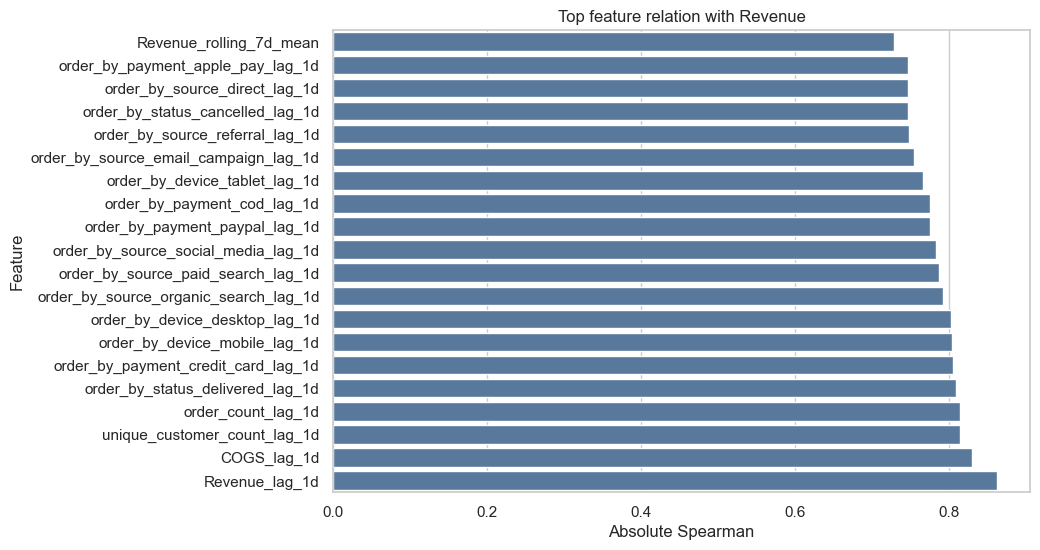

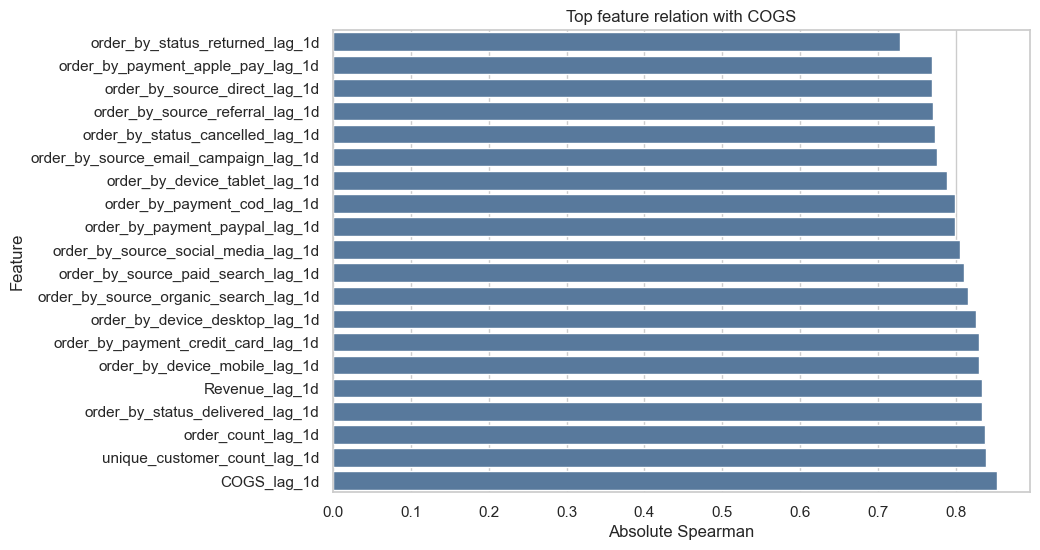

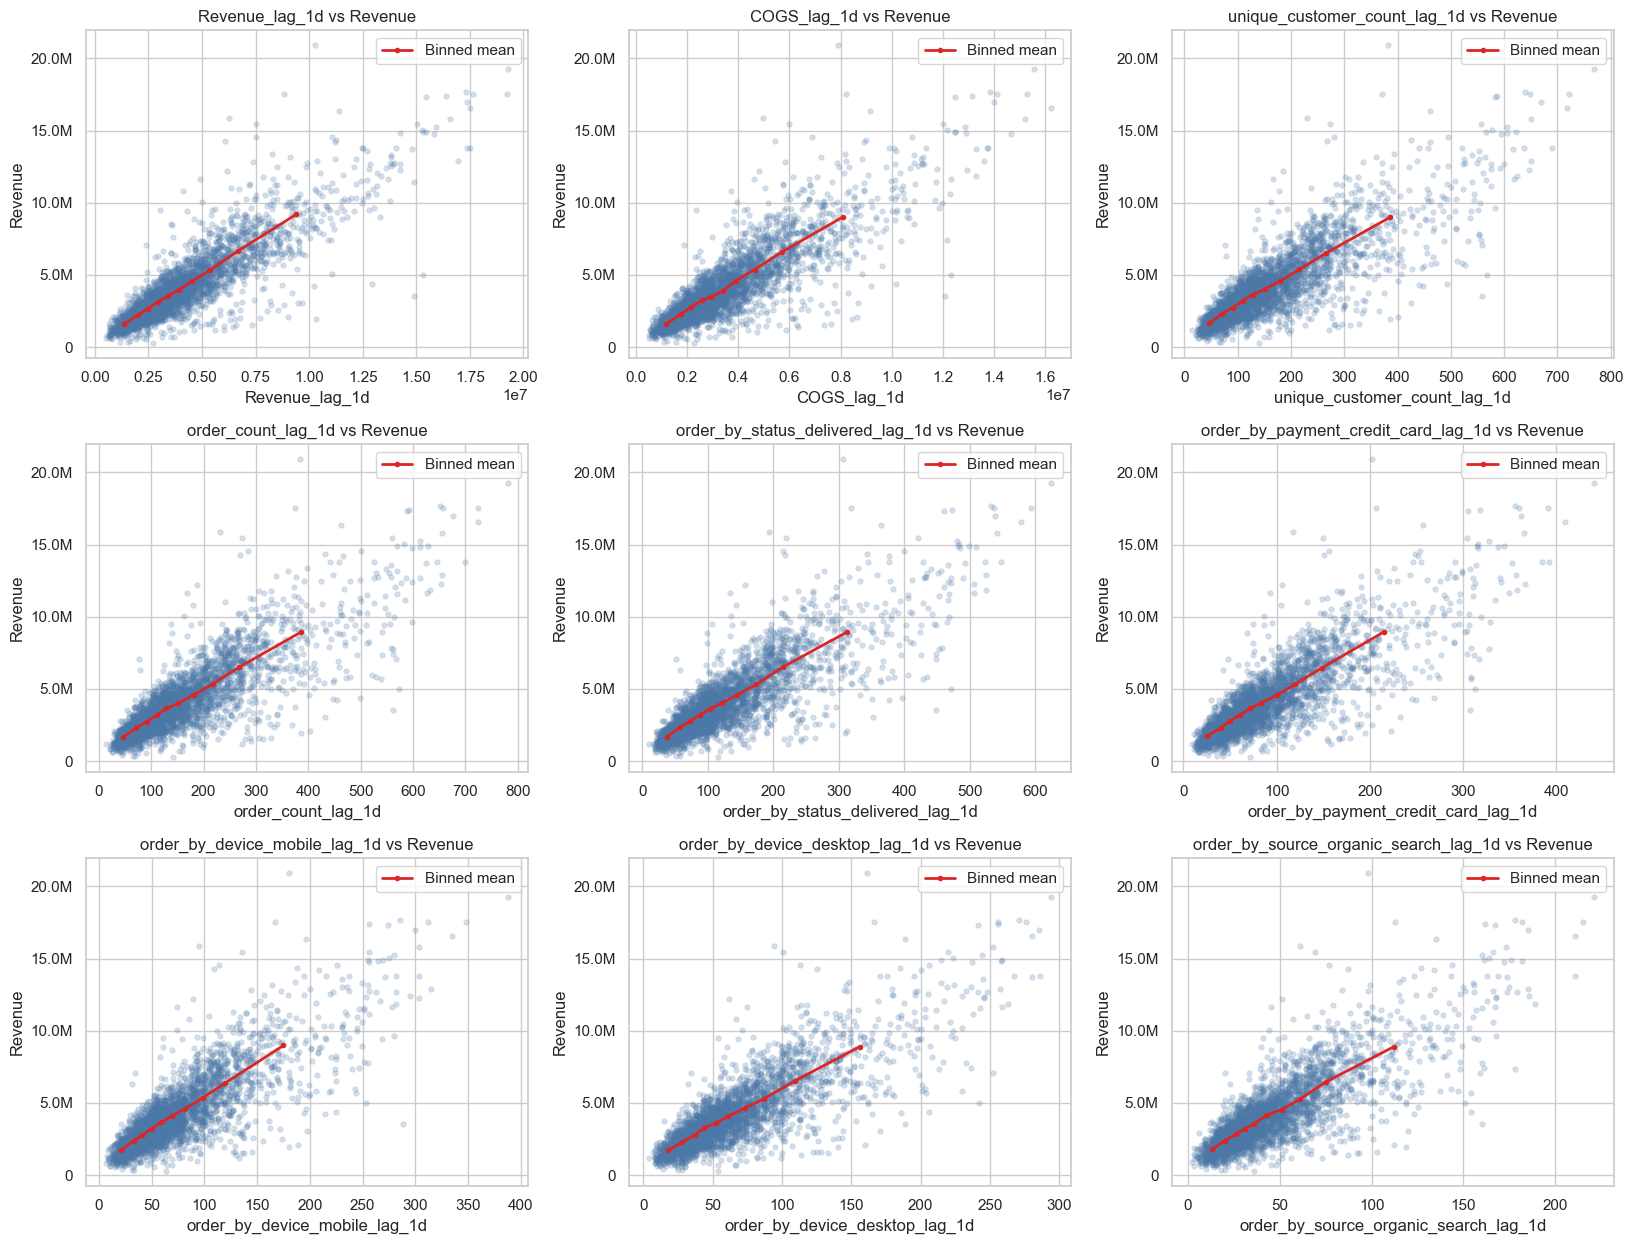

In [ ]:
quality_screen_features = feature_quality_filter.loc[feature_quality_filter['action'].ne('DROP'), 'feature'].tolist()
relation_report = du.target_relation_report(
    candidate_features_daily,
    features=quality_screen_features,
    targets=['Revenue', 'COGS'],
    min_pairs=30,
)

if relation_report.empty:
    feature_relevance_report = pd.DataFrame(columns=['feature', 'Spearman_Revenue', 'Spearman_COGS', 'relation_label', 'action'])
else:
    feature_relevance_report = relation_report.rename(columns={
        'Revenue_spearman': 'Spearman_Revenue',
        'COGS_spearman': 'Spearman_COGS',
        'relation': 'relation_label',
    }).copy()
    def relevance_action(score):
        if pd.isna(score):
            return 'REVIEW'
        if score < RELEVANCE_DROP_THRESHOLD:
            return 'DROP'
        if score < RELEVANCE_REVIEW_THRESHOLD:
            return 'REVIEW'
        return 'KEEP'
    feature_relevance_report['action'] = feature_relevance_report['max_abs_spearman'].map(relevance_action)

save_df(feature_relevance_report, 'feature_relevance_report.csv')

if not relation_report.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    du.plot_target_relation_bars(relation_report, 'Revenue', top=20, ax=ax)
    save_fig('fig_fe_01_spearman_bar_revenue.png')

    fig, ax = plt.subplots(figsize=(9, 6))
    du.plot_target_relation_bars(relation_report, 'COGS', top=20, ax=ax)
    save_fig('fig_fe_02_spearman_bar_cogs.png')

    top_revenue_features = relation_report.dropna(subset=['Revenue_abs_spearman']).nlargest(9, 'Revenue_abs_spearman')['feature'].tolist()
    if top_revenue_features:
        du.plot_feature_grid(candidate_features_daily, top_revenue_features, target='Revenue', n_cols=3, money_axis=True)
        save_fig('fig_fe_03_top_features_vs_revenue.png')

# Sắp xếp theo thứ tự ưu tiên: DROP -> REVIEW -> KEEP để dễ theo dõi các feature yếu
du.show(feature_relevance_report.sort_values('action'), title='feature_relevance_report')


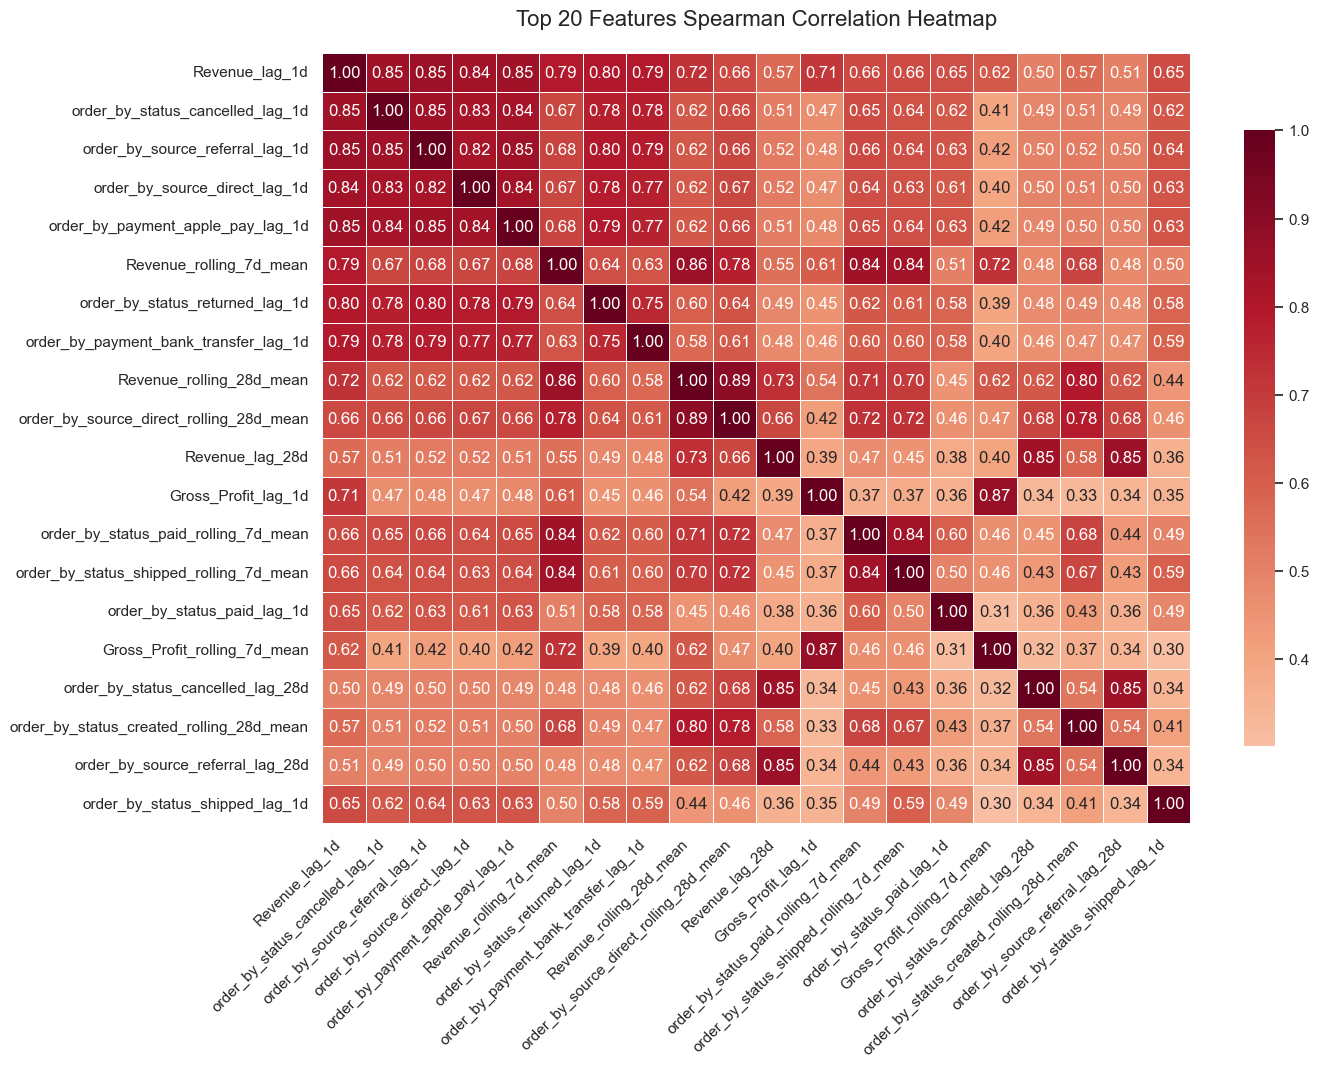

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lấy top 20 features dựa trên score_map đã có
if 'features_after_family_cap' in locals() and 'score_map' in locals():
    top_20_features = sorted(
        features_after_family_cap,
        key=lambda f: score_map.get(f, -np.inf) if pd.notna(score_map.get(f, np.nan)) else -np.inf,
        reverse=True
    )[:20]

    if len(top_20_features) >= 2:
        # Khởi tạo figure
        plt.figure(figsize=(14, 10))

        # Tính toán ma trận tương quan Spearman
        corr_matrix = candidate_features_daily[top_20_features].corr(method='spearman')

        # Vẽ heatmap với seaborn để tùy chỉnh màu sắc và hiển thị số (annot)
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            linewidths=0.5,
            cbar_kws={'shrink': .8}
        )

        plt.title('Top 20 Features Spearman Correlation Heatmap', fontsize=16, pad=20)
        plt.xticks(rotation=45, ha='right')
        plt.show()
    else:
        print("Không đủ dữ liệu đặc trưng để vẽ biểu đồ.")
else:
    print("Không tìm thấy danh sách đặc trưng hoặc bản đồ điểm số.")


In [ ]:
# Tóm tắt số lượng feature trước khi vào Phase 4.3
total_initial = len(feature_candidates)
dropped_quality = len(feature_quality_filter[feature_quality_filter['action'] == 'DROP'])
dropped_relevance = len(feature_relevance_report[feature_relevance_report['action'] == 'DROP'])
remaining_before_redundancy = int(feature_relevance_report['action'].ne('DROP').sum())

filter_stats = pd.DataFrame([
    {'Metric': 'Total Initial Features', 'Count': total_initial},
    {'Metric': 'Dropped by Quality Filter', 'Count': dropped_quality},
    {'Metric': 'Dropped by Relevance Filter', 'Count': dropped_relevance},
    {'Metric': 'Remaining Features for Phase 4.3', 'Count': remaining_before_redundancy},
])

du.show(filter_stats, title='Feature Count Summary Before Phase 4.3')

dropped_examples = feature_relevance_report.loc[
    feature_relevance_report['action'] == 'DROP', 'feature'
].head(10).tolist()
print(f'Examples of features dropped due to low relevance: {dropped_examples}')



Feature Count Summary Before Phase 4.3


,Metric,Count
0,Total Initial Features,190
1,Dropped by Quality Filter,0
2,Dropped by Relevance Filter,6
3,Remaining Features for Phase 4.3,184


Examples of features dropped due to low relevance: ['active_promo_count', 'sin_day_of_week', 'has_stackable_promo', 'day_of_week', 'is_weekend', 'cos_day_of_week']


### Kết luận Phase 4.2 - Univariate Relevance

- Input của Phase 4.2: **190 feature** sau quality filter.
- Metric dùng: **Spearman correlation** với `Revenue` và `COGS`; đây là tương quan theo thứ hạng, không phải tương quan tuyến tính thuần.
- Output `feature_relevance_report.csv` có shape **190 x 15**.
- Kết quả: **6 feature bị DROP**, còn **184 feature** chuyển sang Phase 4.3.
- Các feature bị drop vì `max_abs_spearman < 0.10`: `active_promo_count`, `sin_day_of_week`, `has_stackable_promo`, `day_of_week`, `is_weekend`, `cos_day_of_week`.
- Ví dụ feature yếu nhất trong output: `cos_day_of_week` có max_abs_spearman khoảng **0.054**, `day_of_week` khoảng **0.077**, `active_promo_count` khoảng **0.096**.
- Nhóm feature có signal tốt hơn gồm target history, order lag/rolling và một số calendar feature như `cos_month`.
- Lưu ý DS: Phase 4.2 chỉ kiểm tra từng feature riêng lẻ; feature yếu đơn biến có thể vẫn hữu ích khi kết hợp, nhưng ở vòng này ta ưu tiên giảm nhiễu trước.


## Phase 4.3 - Redundancy & Multicollinearity Filter

- Mục tiêu: giảm feature trùng thông tin và tránh quá nhiều biến cùng một family.
- Dùng correlation giữa các feature để phát hiện cặp quá giống nhau.
- Với cặp redundant, ưu tiên giữ feature liên quan target mạnh hơn hoặc ít missing hơn.
- Family cap giúp tránh giữ quá nhiều lag/rolling của cùng một tín hiệu.
- Output chính: `redundancy_pairs.csv`, `feature_family_cap.csv`, `fig_fe_04_correlation_heatmap.png`.


### Ghi chú thực thi Phase 4.3 - Family Cap

- Family Cap cần chạy sau Redundancy Filter vì dùng biến `features_after_redundancy`.
- Code Family Cap chính nằm ở cell ngay sau phần Redundancy để notebook có thể chạy tuần tự từ trên xuống.


In [ ]:
# Phase 4.3 – Redundancy Filter + Family Cap
# ============================================================

# ── Đảm bảo đầu vào là data sau khi đã loại bỏ các feature ở Phase 4.1 & 4.2
relevance_keep_features = feature_relevance_report.loc[
    feature_relevance_report['action'].ne('DROP'), 'feature'
].tolist()
redundancy_input_features = [
    feature for feature in relevance_keep_features
    if feature in candidate_features_daily.columns
]

print(f"Số lượng đặc trưng đầu vào cho Phase 4.3: {len(redundancy_input_features)}")

# ── Tìm các cặp tương quan cao ──────────────────────────────
if len(redundancy_input_features) >= 2:
    high_corr_raw = du.high_corr_pairs(
        candidate_features_daily,
        cols=redundancy_input_features,
        threshold=HIGH_CORR_THRESHOLD,
        method='spearman',
    )
else:
    high_corr_raw = pd.DataFrame(columns=['feature_a', 'feature_b', 'abs_corr'])

# ── Lookup maps ─────────────────────────────────────────────
score_map = (
    feature_relevance_report.set_index('feature')['max_abs_spearman'].to_dict()
    if 'max_abs_spearman' in feature_relevance_report.columns
    else {}
)
missing_map = feature_quality_filter.set_index('feature')['missing_pct'].to_dict()

# ── Hàm chọn feature giữ lại trong cặp tương quan cao ───────
def choose_redundancy_pair(feature_a, feature_b):
    score_a   = score_map.get(feature_a, -np.inf)
    score_b   = score_map.get(feature_b, -np.inf)
    missing_a = missing_map.get(feature_a, np.inf)
    missing_b = missing_map.get(feature_b, np.inf)
    if pd.notna(score_a) and pd.notna(score_b) and score_a != score_b:
        return (feature_a, feature_b) if score_a > score_b else (feature_b, feature_a)
    if missing_a != missing_b:
        return (feature_a, feature_b) if missing_a < missing_b else (feature_b, feature_a)
    return (feature_a, feature_b)

# ── Redundancy filter ────────────────────────────────────────
redundancy_drop_features = set()
redundancy_rows = []
for _, row in high_corr_raw.iterrows():
    feature_a = row['feature_a']
    feature_b = row['feature_b']
    if feature_a in redundancy_drop_features or feature_b in redundancy_drop_features:
        continue
    kept, dropped = choose_redundancy_pair(feature_a, feature_b)
    redundancy_drop_features.add(dropped)
    redundancy_rows.append({
        'feature_a': feature_a,
        'feature_b': feature_b,
        'abs_corr' : row['abs_corr'],
        'kept'     : kept,
        'dropped'  : dropped,
    })

redundancy_pairs = pd.DataFrame(redundancy_rows)
features_after_redundancy = [
    feature for feature in redundancy_input_features
    if feature not in redundancy_drop_features
]

# ── Hàm infer family (dùng chung cho cell tiếp theo) ────────
def infer_family(feature):
    base = re.sub(r'_lag_\d+d$',           '', feature)
    base = re.sub(r'_rolling_\d+d_mean$',  '', base)
    base = re.sub(r'_diff_1d$',            '', base)
    base = re.sub(r'_pct_change_7d$',      '', base)
    return base

# ── Lưu & hiển thị ──────────────────────────────────────────
save_df(redundancy_pairs, 'redundancy_pairs.csv')
du.show(redundancy_pairs, title='redundancy_pairs')

print(f"\nSố feature sau redundancy filter : {len(features_after_redundancy)}")
print("→ Chạy cell tiếp theo để thực hiện Family Cap")


Số lượng đặc trưng đầu vào cho Phase 4.3: 184
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\redundancy_pairs.csv

redundancy_pairs


,feature_a,feature_b,abs_corr,kept,dropped
0,avg_active_discount,max_active_discount,1.0000,avg_active_discount,max_active_discount
1,unique_customer_count_rolling_28d_mean,order_count_rolling_28d_mean,1.0000,unique_customer_count_rolling_28d_mean,order_count_rolling_28d_mean
2,unique_customer_count_rolling_7d_mean,order_count_rolling_7d_mean,1.0000,unique_customer_count_rolling_7d_mean,order_count_rolling_7d_mean
3,unique_customer_count_lag_14d,order_count_lag_14d,0.9999,unique_customer_count_lag_14d,order_count_lag_14d
4,unique_customer_count_lag_1d,order_count_lag_1d,0.9999,unique_customer_count_lag_1d,order_count_lag_1d
5,unique_customer_count_lag_28d,order_count_lag_28d,0.9999,unique_customer_count_lag_28d,order_count_lag_28d
6,unique_customer_count_lag_7d,order_count_lag_7d,0.9999,unique_customer_count_lag_7d,order_count_lag_7d
7,unique_visitors_rolling_28d_mean,sessions_rolling_28d_mean,0.9998,unique_visitors_rolling_28d_mean,sessions_rolling_28d_mean
8,unique_customer_count_rolling_28d_mean,order_by_payment_credit_card_rolling_28d_mean,0.9995,unique_customer_count_rolling_28d_mean,order_by_payment_credit_card_rolling_28d_mean
9,unique_customer_count_rolling_28d_mean,order_by_status_delivered_rolling_28d_mean,0.9994,unique_customer_count_rolling_28d_mean,order_by_status_delivered_rolling_28d_mean



Số feature sau redundancy filter : 68
→ Chạy cell tiếp theo để thực hiện Family Cap


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\feature_family_cap.csv
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_04_correlation_heatmap.png

Family Cap Summary Report


,family,original_count,kept_count,features_kept,features_dropped
0,Revenue,6,4,"Revenue_lag_1d, Revenue_rolling_7d_mean, Reven...","Revenue_lag_7d, Revenue_lag_14d"
1,order_by_status_cancelled,4,4,"order_by_status_cancelled_lag_1d, order_by_sta...",-
2,order_by_source_referral,4,4,"order_by_source_referral_lag_1d, order_by_sour...",-
3,order_by_source_direct,5,4,"order_by_source_direct_lag_1d, order_by_source...",order_by_source_direct_lag_7d
4,order_by_payment_apple_pay,4,4,"order_by_payment_apple_pay_lag_1d, order_by_pa...",-
5,order_by_status_returned,4,4,"order_by_status_returned_lag_1d, order_by_stat...",-
6,order_by_payment_bank_transfer,4,4,"order_by_payment_bank_transfer_lag_1d, order_b...",-
7,Gross_Profit,4,4,"Gross_Profit_lag_1d, Gross_Profit_rolling_7d_m...",-
8,order_by_status_paid,5,4,"order_by_status_paid_rolling_7d_mean, order_by...",order_by_status_paid_lag_7d
9,order_by_status_shipped,5,4,"order_by_status_shipped_rolling_7d_mean, order...",order_by_status_shipped_lag_7d


None

Final features after Family Cap: 61


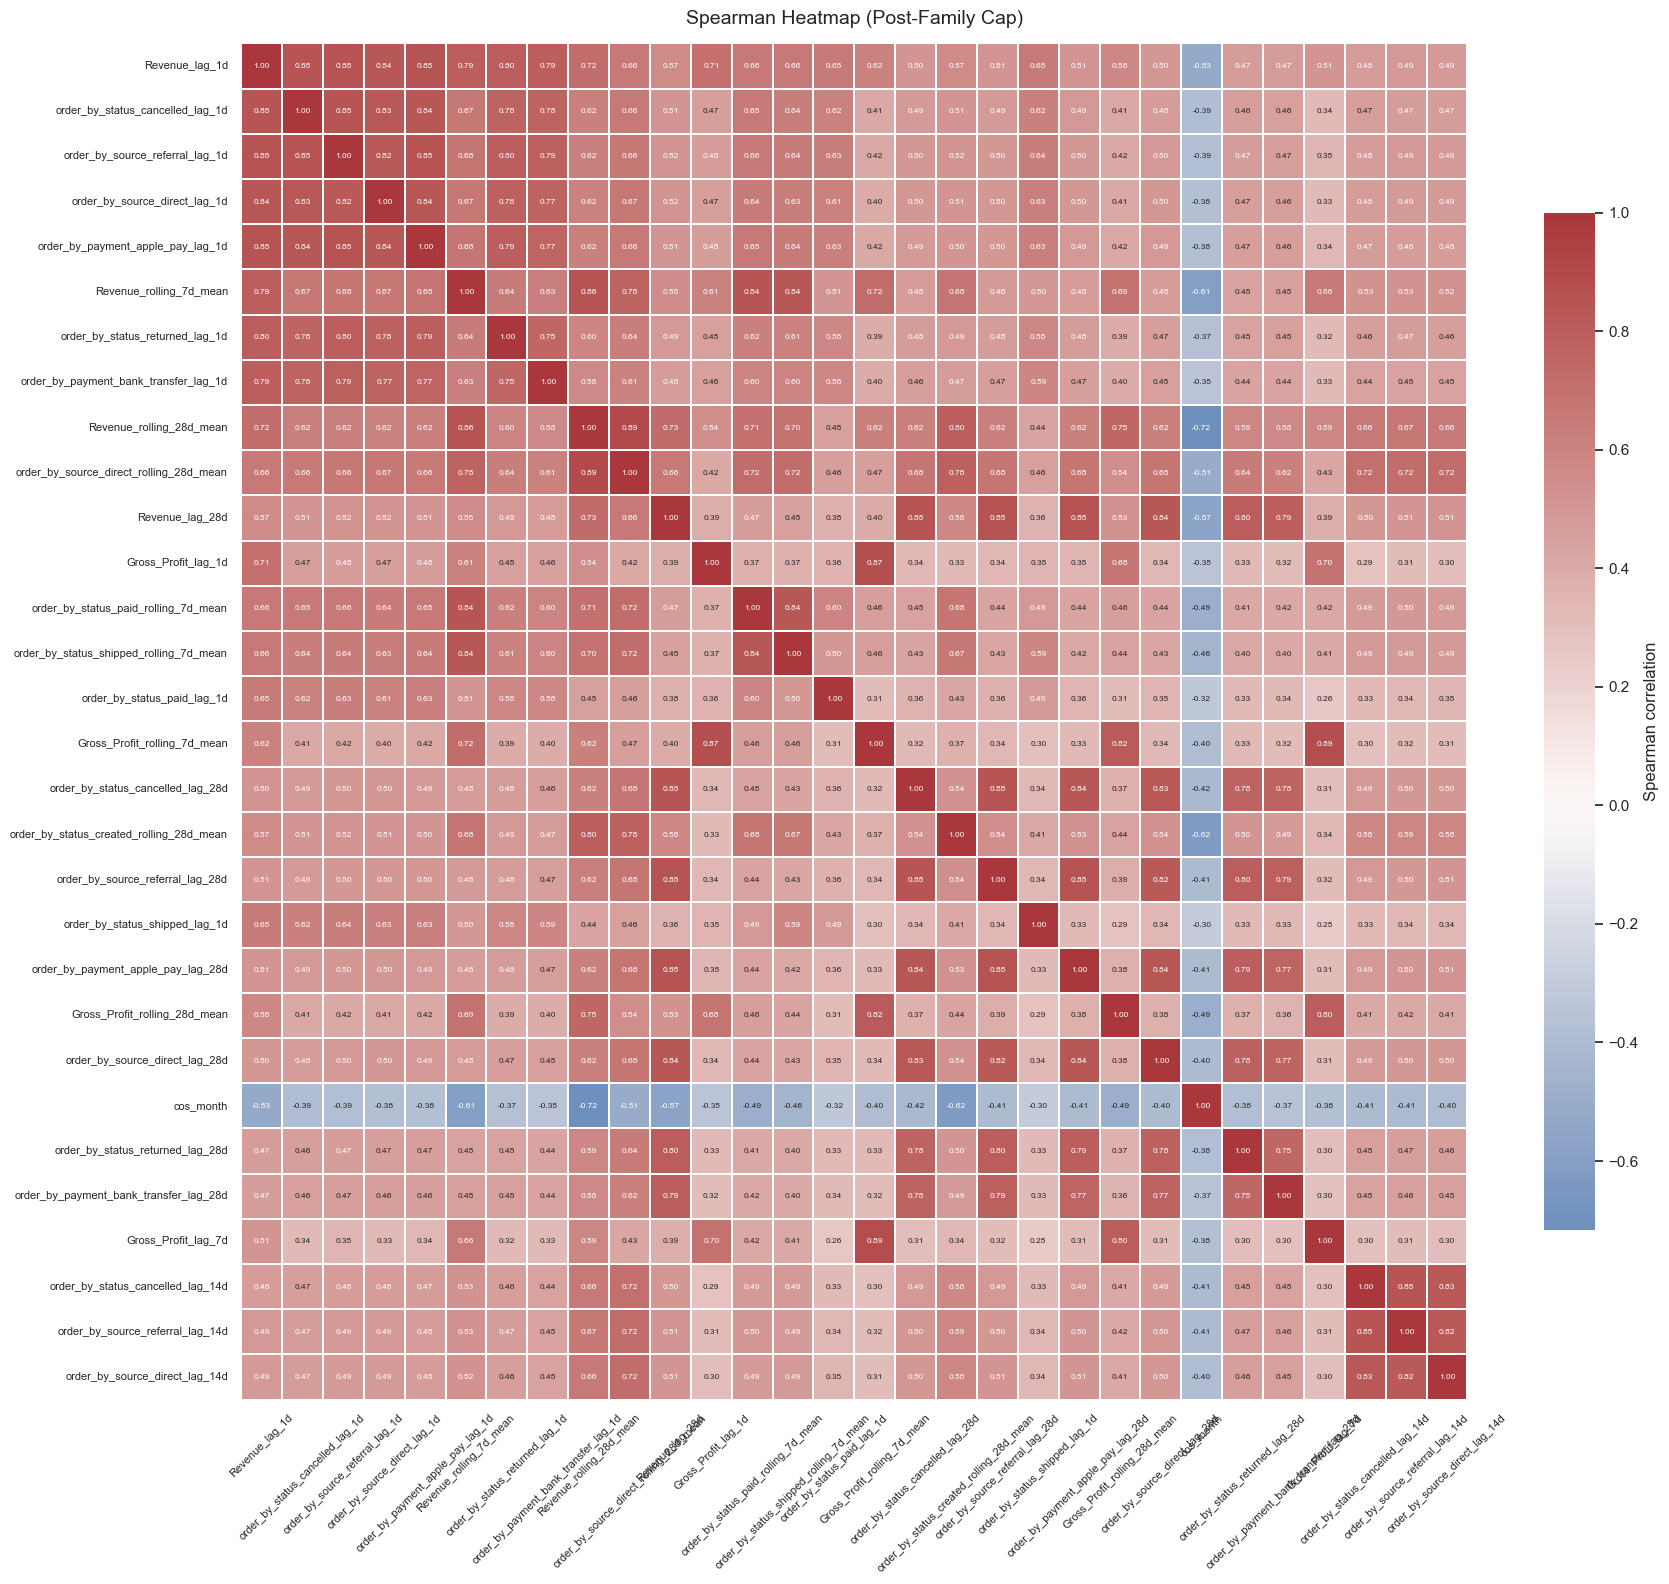

In [ ]:
# ============================================================
# Phase 4.3 (Cont.) – Implementation of Family Cap
# ============================================================

# Group the features that survived the redundancy filter into families
lag_roll_features = [f for f in features_after_redundancy if re.search(r'_(lag_\d+d|rolling_\d+d_mean)$', f)]
family_map = {}
for feature in lag_roll_features:
    family_map.setdefault(infer_family(feature), []).append(feature)

family_rows = []
family_drop_features = set()

# Apply the limit (FAMILY_CAP) to each family based on Rank (Score > Quality)
for family, features in family_map.items():
    ranked = sorted(
        features,
        key=lambda f: (
            -float(score_map.get(f, -np.inf)),
            float(missing_map.get(f, np.inf)),
            f
        )
    )

    kept_features = ranked[:FAMILY_CAP]
    dropped_features = ranked[FAMILY_CAP:]
    family_drop_features.update(dropped_features)

    family_rows.append({
        'family': family,
        'original_count': len(features),
        'kept_count': len(kept_features),
        'features_kept': ', '.join(kept_features),
        'features_dropped': ', '.join(dropped_features) if dropped_features else '-'
    })

feature_family_cap = pd.DataFrame(family_rows)
features_after_family_cap = [f for f in features_after_redundancy if f not in family_drop_features]

# Save and Display
save_df(feature_family_cap, 'feature_family_cap.csv')

# Visualization: Top 30 features correlation after Cap
heatmap_features = sorted(
    features_after_family_cap,
    key=lambda f: score_map.get(f, -np.inf),
    reverse=True
)[:30]

if len(heatmap_features) >= 2:
    corr_matrix = candidate_features_daily[heatmap_features].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(
        corr_matrix,
        cmap='vlag',
        center=0,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 6},
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'shrink': 0.75, 'label': 'Spearman correlation'},
        ax=ax,
    )
    ax.set_title('Spearman Heatmap (Post-Family Cap)', fontsize=14, pad=14)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    save_fig('fig_fe_04_correlation_heatmap.png')

display(du.show(feature_family_cap, title='Family Cap Summary Report'))
print(f"Final features after Family Cap: {len(features_after_family_cap)}")


In [ ]:
# Calculate counts for Phase 4.3 summary
count_in_43 = len(redundancy_input_features)
count_dropped_redundancy = len(redundancy_drop_features)
count_after_redundancy = len(features_after_redundancy)
count_dropped_family = len(family_drop_features)
count_final_43 = len(features_after_family_cap)

# Create summary table
phase_43_stats = pd.DataFrame([
    {'Metric': 'Input Features (from Phase 4.2)', 'Count': count_in_43},
    {'Metric': 'Dropped by Redundancy Filter (>0.90)', 'Count': count_dropped_redundancy},
    {'Metric': 'Features after Redundancy Filter', 'Count': count_after_redundancy},
    {'Metric': 'Dropped by Family Cap (>4 per signal)', 'Count': count_dropped_family},
    {'Metric': 'Final Features after Phase 4.3', 'Count': count_final_43}
])

du.show(phase_43_stats, title='Phase 4.3 Feature Filtering Summary')

# List top kept features for context
top_kept = sorted(features_after_family_cap, key=lambda f: score_map.get(f, 0), reverse=True)[:5]
print(f'Top 5 strongest kept features: {top_kept}')



Phase 4.3 Feature Filtering Summary


,Metric,Count
0,Input Features (from Phase 4.2),184
1,Dropped by Redundancy Filter (>0.90),116
2,Features after Redundancy Filter,68
3,Dropped by Family Cap (>4 per signal),7
4,Final Features after Phase 4.3,61


Top 5 strongest kept features: ['Revenue_lag_1d', 'order_by_status_cancelled_lag_1d', 'order_by_source_referral_lag_1d', 'order_by_source_direct_lag_1d', 'order_by_payment_apple_pay_lag_1d']


### Kết luận Phase 4.3 - Redundancy Filter & Family Cap

- Input của Phase 4.3: **184 feature** sau relevance filter.
- Redundancy filter phát hiện và xuất **116 cặp feature tương quan cao** vào `redundancy_pairs.csv`.
- Ví dụ cặp gần trùng thông tin:
  - `avg_active_discount` vs `max_active_discount`, abs_corr = **0.999983**.
  - `unique_customer_count_rolling_28d_mean` vs `order_count_rolling_28d_mean`, abs_corr = **0.999976**.
  - `unique_customer_count_lag_1d` vs `order_count_lag_1d`, abs_corr = **0.999916**.
- Sau redundancy filter, số feature giảm từ **184 xuống 68**.
- Family cap phát hiện **15 family**, trong đó **5 family bị capped**.
- Family cap drop thêm **7 feature**, còn **61 feature** sau Phase 4.3.
- Ví dụ family bị capped:
  - `Revenue`: giữ `Revenue_lag_1d`, `Revenue_rolling_7d_mean`, `Revenue_rolling_28d_mean`, `Revenue_lag_28d`; drop `Revenue_lag_7d`, `Revenue_lag_14d`.
  - `order_by_source_direct`: drop `order_by_source_direct_lag_7d`.
  - `order_by_status_paid`: drop `order_by_status_paid_lag_7d`.
  - `order_by_status_shipped`: drop `order_by_status_shipped_lag_7d`.
- Quyết định DS: giảm feature trùng thông tin để model gọn hơn, giảm overfit và tránh một nhóm tín hiệu chiếm quá nhiều trọng số.


## Phase 4.4 - Temporal Stability Check

- Mục tiêu: kiểm tra quan hệ giữa feature và target có ổn định qua các giai đoạn thời gian không.
- Feature tốt không chỉ mạnh ở toàn bộ data, mà còn không đổi dấu hoặc mất tín hiệu ở giai đoạn gần đây.
- Đây là kiểm tra stability của signal, không phải kiểm tra distribution drift đầy đủ.
- Feature bị FLAG cần review kỹ trước khi đưa vào wrapper/model.
- Output chính: `feature_stability_report.csv`, `fig_fe_05_stability_lines.png`.


Số lượng đặc trưng đưa vào Phase 4.4 (Stability Check): 61
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\feature_stability_report.csv
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_05_stability_lines.png

feature_stability_report (Sorted by Priority)


,feature,spearman_by_year,stable_flag
58,sin_month,2012:-0.0882; 2013:0.2211; 2014:0.2582; 2015:0...,FLAG
60,year,,REVIEW
0,Gross_Margin_lag_1d,2012:0.1438; 2013:0.1616; 2014:0.0747; 2015:0....,PASS
1,Gross_Margin_lag_7d,2012:0.0530; 2013:0.1779; 2014:0.0531; 2015:0....,PASS
2,Gross_Margin_rolling_28d_mean,2012:0.2988; 2013:0.0555; 2014:0.0909; 2015:0....,PASS
3,Gross_Margin_rolling_7d_mean,2012:0.1970; 2013:0.1871; 2014:0.0186; 2015:0....,PASS
4,Gross_Profit_lag_1d,2012:0.6249; 2013:0.5238; 2014:0.6202; 2015:0....,PASS
5,Gross_Profit_lag_7d,2012:0.2202; 2013:0.3901; 2014:0.4486; 2015:0....,PASS
6,Gross_Profit_rolling_28d_mean,2012:0.2511; 2013:0.3270; 2014:0.4935; 2015:0....,PASS
7,Gross_Profit_rolling_7d_mean,2012:0.3685; 2013:0.4437; 2014:0.5124; 2015:0....,PASS


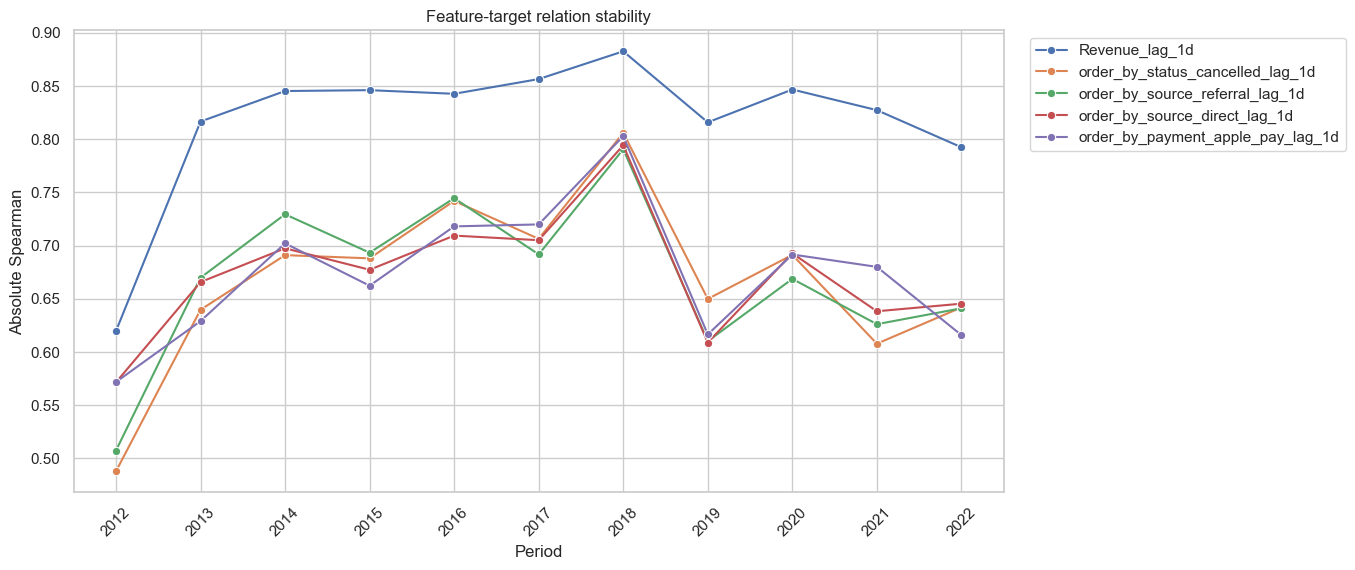

In [ ]:
# Đảm bảo đầu vào Phase 4.4 chỉ lấy các feature đã được lọc qua Phase 4.3
stability_features = [f for f in features_after_family_cap if f in candidate_features_daily.columns]

print(f"Số lượng đặc trưng đưa vào Phase 4.4 (Stability Check): {len(stability_features)}")

if stability_features:
    temporal_report = du.temporal_relation_report(
        candidate_features_daily,
        date_col='Date',
        features=stability_features,
        target='Revenue',
        period='Y',
        min_pairs=30,
    )
else:
    temporal_report = pd.DataFrame(columns=['feature', 'period', 'spearman', 'abs_spearman'])

if not temporal_report.empty:
    period_order = sorted(temporal_report['period'].dropna().unique().tolist())
    recent_periods = set(period_order[-2:])
    stability_rows = []

    for feature, group in temporal_report.groupby('feature'):
        valid = group.dropna(subset=['spearman']).sort_values('period')
        # Kiểm tra sự ổn định của dấu tương quan
        signs = np.sign(valid.loc[valid['spearman'].abs().ge(1e-9), 'spearman'])
        sign_stable = signs.nunique() <= 1
        recent_present = bool(not valid.empty and valid['period'].iloc[-1] in recent_periods)

        if valid.empty:
            stable_flag = 'REVIEW'
        elif sign_stable and recent_present:
            stable_flag = 'PASS'
        else:
            stable_flag = 'FLAG'

        stability_rows.append({
            'feature': feature,
            'spearman_by_year': '; '.join(f"{row.period}:{row.spearman:.4f}" for row in valid.itertuples()),
            'stable_flag': stable_flag,
        })

    feature_stability_report = pd.DataFrame(stability_rows)

    # Sắp xếp ưu tiên: FLAG -> REVIEW -> PASS
    status_priority = {'FLAG': 0, 'REVIEW': 1, 'PASS': 2}
    feature_stability_report['sort_idx'] = feature_stability_report['stable_flag'].map(status_priority)
    feature_stability_report = feature_stability_report.sort_values(['sort_idx', 'feature']).drop(columns=['sort_idx'])

    save_df(feature_stability_report, 'feature_stability_report.csv')
    stable_pass_features = feature_stability_report.loc[
        feature_stability_report['stable_flag'].eq('PASS'), 'feature'
    ].tolist()
    stable_non_flag_features = feature_stability_report.loc[
        feature_stability_report['stable_flag'].ne('FLAG'), 'feature'
    ].tolist()

    # Vẽ biểu đồ cho Top Features
    top_stability_plot = [f for f in top_kept if f in stability_features][:8]
    if top_stability_plot:
        fig, ax = plt.subplots(figsize=(12, 6))
        du.plot_temporal_relation(temporal_report, top_features=top_stability_plot, ax=ax)
        save_fig('fig_fe_05_stability_lines.png')

    du.show(feature_stability_report, title='feature_stability_report (Sorted by Priority)')
else:
    print("Không có dữ liệu temporal để báo cáo.")


In [ ]:
if 'feature_stability_report' in locals():
    stability_counts = feature_stability_report['stable_flag'].value_counts().reset_index()
    stability_counts.columns = ['Status', 'Count']
    du.show(stability_counts, title='Thống kê trạng thái ổn định (Phase 4.4)')
else:
    print('Không tìm thấy báo cáo feature_stability_report.')



Thống kê trạng thái ổn định (Phase 4.4)


,Status,Count
0,PASS,59
1,FLAG,1
2,REVIEW,1


In [ ]:
import pandas as pd
import re

# 1. Lọc danh sách feature còn lại sau Phase 4.4 (loại bỏ FLAG)
pre_wrapper_features = feature_stability_report[feature_stability_report['stable_flag'] != 'FLAG']['feature'].tolist()

# 2. Ánh xạ thông tin từ catalog
pre_wrapper_df = pd.DataFrame({'feature': pre_wrapper_features})
pre_wrapper_df = pre_wrapper_df.merge(feature_catalog[['feature', 'source_table', 'type']], on='feature', how='left')

# 3. Định nghĩa hàm bóc tách Family
def derive_family_simple(name):
    return re.sub(r'_(lag_\d+d|rolling_\d+d_mean|diff_\d+d|pct_change_\d+d)$', '', name)

pre_wrapper_df['family'] = pre_wrapper_df['feature'].apply(derive_family_simple)

# 4. Thống kê theo Source và Family
pre_wrapper_stats = pre_wrapper_df.groupby(['source_table', 'family']).size().reset_index(name='feature_count')

print(f"📊 THỐNG KÊ {len(pre_wrapper_features)} ĐẶC TRƯNG TRƯỚC BƯỚC 4.5:")
du.show(pre_wrapper_stats.sort_values(['source_table', 'feature_count'], ascending=[True, False]),
        title='Feature Inventory Before Phase 4.5 (by Source & Family)')

# 5. Tóm tắt nhanh theo Source
source_summary = pre_wrapper_df['source_table'].value_counts().reset_index()
source_summary.columns = ['Nguồn dữ liệu', 'Tổng số biến']
du.show(source_summary, title='Summary by Source Table')

print(f"Số lượng nhóm logic (Families) tham gia: {pre_wrapper_df['family'].nunique()}")


📊 THỐNG KÊ 60 ĐẶC TRƯNG TRƯỚC BƯỚC 4.5:

Feature Inventory Before Phase 4.5 (by Source & Family)


,source_table,family,feature_count
0,Date,cos_month,1
1,Date,day_of_month,1
2,Date,is_month_end,1
3,Date,is_month_start,1
4,Date,quarter,1
5,Date,year,1
6,orders,order_by_payment_apple_pay,4
7,orders,order_by_payment_bank_transfer,4
8,orders,order_by_source_direct,4
9,orders,order_by_source_referral,4



Summary by Source Table


,Nguồn dữ liệu,Tổng số biến
0,orders,36
1,sales,14
2,Date,6
3,web_traffic,3
4,promotions,1


Số lượng nhóm logic (Families) tham gia: 22


### Kết luận Phase 4.4 - Temporal Stability

- Input của Phase 4.4: **61 feature** sau redundancy filter và family cap.
- Output `feature_stability_report.csv` có shape **61 x 3**.
- Kết quả stability:
  - **59 feature PASS**: quan hệ feature-target ổn định hơn qua các năm.
  - **1 feature FLAG**: `sin_month`, vì dấu tương quan đổi chiều theo năm.
  - **1 feature REVIEW**: `year`, vì đây là biến trend dài hạn, cần cân nhắc theo mục tiêu forecast.
- Sau khi loại nhóm FLAG, wrapper pool còn **60 feature** để đưa sang Phase 4.5.
- Ví dụ feature PASS quan trọng: `Revenue_lag_1d`, `Revenue_rolling_7d_mean`, `Gross_Profit_lag_1d`, `Gross_Profit_rolling_7d_mean`, `cos_month`, `day_of_month`.
- Quyết định DS: không dùng `sin_month` trong pool cuối vì signal không ổn định; `year` được giữ để wrapper quyết định vì có thể đại diện trend dài hạn.


## Phase 4.5 - Time-Aware Wrapper

- Mục tiêu: dùng validation theo thời gian để kiểm tra feature group/family có giúp giảm WAPE không.
- Wrapper không phải model cuối cùng, chỉ là công cụ hỗ trợ chọn feature.
- Baseline dùng target history và calendar; các nhóm traffic, orders, promotions được thêm vào để xem có cải thiện không.
- Nếu một nhóm làm WAPE xấu đi hoặc không cải thiện, nhóm đó không nên được ưu tiên cho final feature set.
- Output chính: `wrapper_incremental_wape.csv`, `family_granular_wrapper.csv`, `fig_fe_06_incremental_wape.png`.


Số lượng đặc trưng sau khi lọc từ phase 4.4: 60
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\wrapper_incremental_wape.csv
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_06_incremental_wape.png

wrapper_incremental_wape


,feature_group,feature_count,wape_without,wape_with,delta,decision
0,baseline_target_lag_rolling,14,NaN,0.2216,NaN,BASELINE
1,calendar_features,20,0.2216,0.2021,-0.0194,KEEP
2,traffic_features,23,0.2021,0.2037,0.0016,REVIEW
3,order_features,59,0.2037,0.2036,-0.0001,REVIEW
4,promo_features,60,0.2036,0.2027,-0.0009,REVIEW


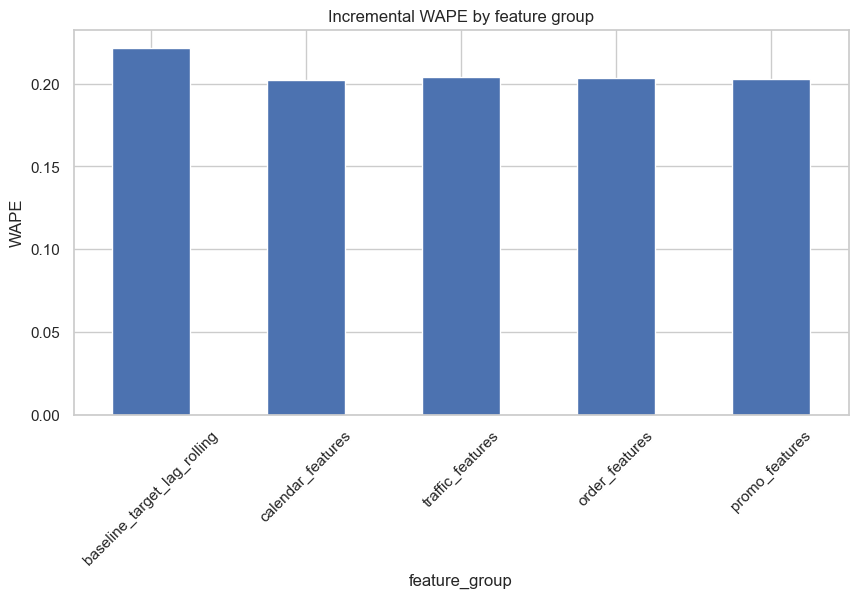

In [ ]:
try:
    from lightgbm import LGBMRegressor
    WRAPPER_MODEL_BACKEND = 'lightgbm'
except Exception:
    LGBMRegressor = None
    WRAPPER_MODEL_BACKEND = 'manual_ridge'

# --- DATA INTEGRITY CHECK (Phase 4.4 -> 4.5) ---
if 'feature_stability_report' in locals() and 'stability_features' in locals():
    report_features = feature_stability_report[feature_stability_report['stable_flag'] != 'FLAG']['feature'].tolist()
    print(f'Số lượng đặc trưng sau khi lọc từ phase 4.4: {len(report_features)}')


def fit_predict_wrapper(X_train, y_train, X_test, alpha=1.0):
    if WRAPPER_MODEL_BACKEND == 'lightgbm':
        model = LGBMRegressor(
            n_estimators=120,
            learning_rate=0.05,
            max_depth=3,
            num_leaves=15,
            random_state=RANDOM_STATE,
            verbose=-1,
        )
        model.fit(X_train, y_train)
        return model.predict(X_test)

    train_medians = X_train.median(axis=0)
    Xtr = X_train.fillna(train_medians).to_numpy(dtype=float)
    Xte = X_test.fillna(train_medians).to_numpy(dtype=float)
    y = np.asarray(y_train, dtype=float)

    col_mean = np.nanmean(Xtr, axis=0)
    col_std = np.nanstd(Xtr, axis=0)
    col_std = np.where((col_std == 0) | np.isnan(col_std), 1.0, col_std)
    Xtr = (Xtr - col_mean) / col_std
    Xte = (Xte - col_mean) / col_std

    Xtr_design = np.column_stack([np.ones(len(Xtr)), Xtr])
    Xte_design = np.column_stack([np.ones(len(Xte)), Xte])
    penalty = np.eye(Xtr_design.shape[1])
    penalty[0, 0] = 0
    beta = np.linalg.pinv(Xtr_design.T @ Xtr_design + alpha * penalty) @ Xtr_design.T @ y
    return Xte_design @ beta

def rolling_origin_wape(df, features, target='Revenue', date_col='Date', min_train_days=365 * 3, test_days=30, step_days=90, max_folds=6):
    data = df[[date_col, target] + list(features)].sort_values(date_col).dropna(subset=[target]).copy()
    min_date = data[date_col].min()
    max_date = data[date_col].max()
    first_origin = min_date + pd.Timedelta(days=min_train_days)
    last_origin = max_date - pd.Timedelta(days=test_days)
    if first_origin >= last_origin:
        return np.nan
    origins = pd.date_range(start=first_origin, end=last_origin, freq=f'{step_days}D')
    origins = origins[-max_folds:]
    fold_wapes = []
    for origin in origins:
        train = data[data[date_col] < origin]
        test = data[(data[date_col] >= origin) & (data[date_col] < origin + pd.Timedelta(days=test_days))]
        if len(train) < 30 or test.empty:
            continue
        if not features:
            pred = np.repeat(train[target].mean(), len(test))
        else:
            X_train = train[list(features)].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
            y_train = train[target]
            X_test = test[list(features)].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
            pred = fit_predict_wrapper(X_train, y_train, X_test)
        fold_wapes.append(du.wape(test[target], pred))
    return float(np.nanmean(fold_wapes)) if fold_wapes else np.nan

# --- Wrapper Execution ---
stability_status_map = feature_stability_report.set_index('feature')['stable_flag'].to_dict() if not feature_stability_report.empty else {}
wrapper_pool = [feature for feature in stability_features if stability_status_map.get(feature, 'PASS') != 'FLAG']

catalog_source = feature_catalog.set_index('feature')['source_table'].to_dict()
catalog_type = feature_catalog.set_index('feature')['type'].to_dict()

def pool_by_source(source):
    return [feature for feature in wrapper_pool if catalog_source.get(feature) == source]

target_history_features = [
    feature for feature in wrapper_pool
    if catalog_source.get(feature) == 'sales' and catalog_type.get(feature) in {'lag', 'rolling', 'diff', 'change'}
]

feature_group_sequence = [
    ('baseline_target_lag_rolling', target_history_features),
    ('calendar_features', pool_by_source('Date')),
    ('traffic_features', pool_by_source('web_traffic')),
    ('order_features', pool_by_source('orders')),
    ('promo_features', pool_by_source('promotions')),
]

wrapper_rows = []
current_features = []
previous_wape = np.nan
for group_name, add_features in feature_group_sequence:
    current_features = list(dict.fromkeys(current_features + add_features))
    if RUN_OPTIONAL_WRAPPER:
        current_wape = rolling_origin_wape(candidate_features_daily, current_features, target='Revenue')
    else:
        current_wape = np.nan
    delta = current_wape - previous_wape if pd.notna(current_wape) and pd.notna(previous_wape) else np.nan

    decision = 'KEEP' if pd.notna(delta) and delta < -0.001 else ('BASELINE' if group_name.startswith('baseline') else 'REVIEW')

    wrapper_rows.append({
        'feature_group': group_name,
        'feature_count': len(current_features),
        'wape_without': previous_wape,
        'wape_with': current_wape,
        'delta': delta,
        'decision': decision,
    })
    previous_wape = current_wape

wrapper_incremental_wape = pd.DataFrame(wrapper_rows)
save_df(wrapper_incremental_wape, 'wrapper_incremental_wape.csv')

if RUN_OPTIONAL_WRAPPER and wrapper_incremental_wape['wape_with'].notna().any():
    fig, ax = plt.subplots(figsize=(10, 5))
    wrapper_incremental_wape.plot(kind='bar', x='feature_group', y='wape_with', ax=ax, legend=False)
    ax.set_ylabel('WAPE')
    ax.set_title('Incremental WAPE by feature group')
    ax.tick_params(axis='x', rotation=45)
    save_fig('fig_fe_06_incremental_wape.png')

du.show(wrapper_incremental_wape, title='wrapper_incremental_wape')


### Phase 4.5.1 - Granular Family-Level Wrapper Analysis

- Mục tiêu: kiểm tra sâu hơn từng family feature sau wrapper theo nhóm lớn.
- Cách này giúp biết family nào thật sự tạo thêm giá trị dự báo so với baseline.
- Kết quả family wrapper dùng để chốt danh sách feature tự động cuối cùng.


In [ ]:
def infer_family(feature):
    base = re.sub(r'_(lag_\d+d|rolling_\d+d_mean|diff_\d+d|pct_change_\d+d)$', '', feature)
    return base

# 1. Define the baseline (Target History + Calendar which were already 'KEEP')
baseline_features = list(dict.fromkeys(target_history_features + pool_by_source('Date')))
base_wape = rolling_origin_wape(candidate_features_daily, baseline_features, target='Revenue')
print(f"Baseline WAPE (Target + Calendar): {base_wape:.5f}")

# 2. Identify candidate families from the REVIEW groups
review_pool = [f for f in wrapper_pool if f not in baseline_features]
family_to_features = {}
for f in review_pool:
    fam = infer_family(f)
    family_to_features.setdefault(fam, []).append(f)

# 3. Test each family incrementally against the baseline
family_wrapper_results = []
for family, f_list in family_to_features.items():
    test_features = baseline_features + f_list
    current_wape = rolling_origin_wape(candidate_features_daily, test_features, target='Revenue')
    improvement = base_wape - current_wape

    family_wrapper_results.append({
        'family': family,
        'source': catalog_source.get(f_list[0]),
        'feature_count': len(f_list),
        'wape_with_family': current_wape,
        'improvement': improvement,
        'decision': 'POTENTIAL KEEP' if improvement > 0.0005 else 'NO GAIN'
    })

family_wrapper_df = pd.DataFrame(family_wrapper_results).sort_values('improvement', ascending=False)
save_df(family_wrapper_df, 'family_granular_wrapper.csv')
du.show(family_wrapper_df, title='Granular Family Wrapper Performance')


Baseline WAPE (Target + Calendar): 0.20212
Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\tables\family_granular_wrapper.csv

Granular Family Wrapper Performance


,family,source,feature_count,wape_with_family,improvement,decision
10,page_views,web_traffic,1,0.2003,0.0018,POTENTIAL KEEP
4,order_by_status_returned,orders,4,0.2016,0.0005,NO GAIN
11,unique_visitors,web_traffic,1,0.2017,0.0004,NO GAIN
12,avg_active_discount,promotions,1,0.2028,-0.0007,NO GAIN
8,order_by_status_created,orders,4,0.2032,-0.0011,NO GAIN
5,order_by_payment_bank_transfer,orders,4,0.2032,-0.0011,NO GAIN
6,order_by_status_paid,orders,4,0.2034,-0.0013,NO GAIN
9,sessions,web_traffic,1,0.2034,-0.0013,NO GAIN
7,order_by_status_shipped,orders,4,0.2042,-0.0021,NO GAIN
1,order_by_source_referral,orders,4,0.2045,-0.0024,NO GAIN


In [ ]:
# 1. Tính toán số lượng feature cuối cùng sau Phase 4.5
# Lấy các feature từ wrapper mang lại improvement (page_views) kết hợp với baseline
keep_from_granular = family_wrapper_df[family_wrapper_df['decision'] == 'POTENTIAL KEEP']['family'].tolist()
features_from_wrapper = [f for f in wrapper_pool if infer_family(f) in keep_from_granular]

# Kết hợp với các biến baseline (Target + Calendar)
final_pool_preview = list(set(baseline_features + features_from_wrapper))

# 2. Thống kê nguồn gốc
preview_catalog = feature_catalog[feature_catalog['feature'].isin(final_pool_preview)]
source_stats = preview_catalog['source_table'].value_counts().reset_index()
source_stats.columns = ['Nguồn dữ liệu', 'Số lượng biến']

# 3. Hiển thị
print(f"📊 TỔNG CỘNG: {len(final_pool_preview)} đặc trưng đã được chọn lọc sau Phase 4.5")
du.show(source_stats, title='Phân bổ đặc trưng theo nguồn (Sau Phase 4.5)')

# Hiển thị danh sách các Family đại diện
final_families = sorted(list(set([infer_family(f) for f in final_pool_preview])))
print(f"\n🧬 Các nhóm tín hiệu (Families) được giữ lại: {', '.join(final_families)}")


📊 TỔNG CỘNG: 21 đặc trưng đã được chọn lọc sau Phase 4.5

Phân bổ đặc trưng theo nguồn (Sau Phase 4.5)


,Nguồn dữ liệu,Số lượng biến
0,sales,14
1,Date,6
2,web_traffic,1



🧬 Các nhóm tín hiệu (Families) được giữ lại: Gross_Margin, Gross_Profit, Revenue, cos_month, day_of_month, is_month_end, is_month_start, page_views, quarter, year


Saved: B:\Dự án VSF\VinuniDatathon\report_5_6_2026\fe_outputs\figures\fig_fe_07_final_family_audit.png
PHASE 4.5 FINAL SELECTION PREVIEW
- Total Initial Candidates: 190
- Final Automated Selection Preview: 21
- Baseline Features: 20
- Wrapper-added Features: 1

Final Feature Preview by Source and Type


type,calendar,change,diff,lag,rolling
source_table,,,,,
Date,6,0,0,0,0
sales,0,1,1,6,6
web_traffic,0,0,0,1,0


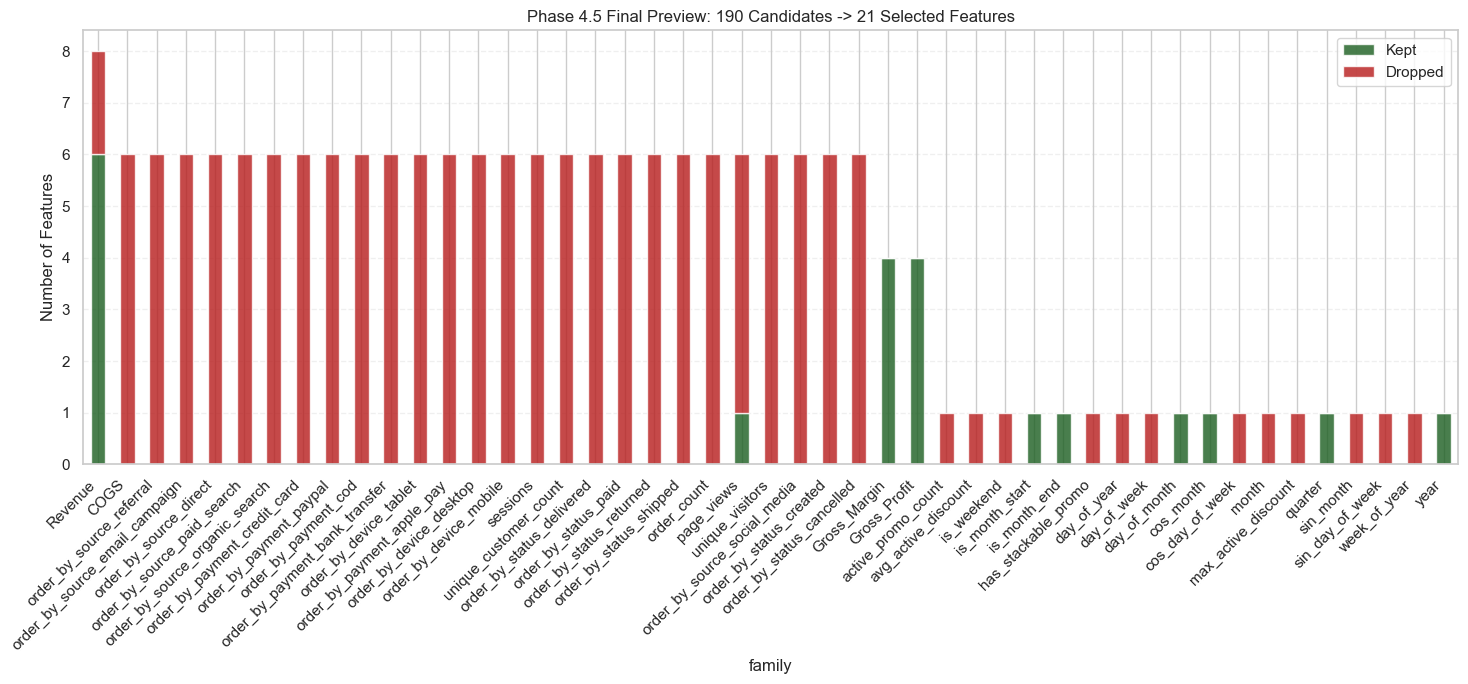

In [ ]:
# Phase 4.5 - Preview danh sách feature cuối theo kết quả wrapper
final_features_preview = list(dict.fromkeys(baseline_features + features_from_wrapper))

final_catalog_summary = feature_catalog[feature_catalog['feature'].isin(final_features_preview)].copy()
final_catalog_summary['family'] = final_catalog_summary['feature'].apply(infer_family)

all_candidates_summary = feature_catalog.copy()
all_candidates_summary['family'] = all_candidates_summary['feature'].apply(infer_family)

family_audit = all_candidates_summary.groupby('family').size().reset_index(name='initial_count')
final_family_counts = final_catalog_summary.groupby('family').size().reset_index(name='kept_count')
family_audit = family_audit.merge(final_family_counts, on='family', how='left').fillna(0)
family_audit['dropped_count'] = family_audit['initial_count'] - family_audit['kept_count']
family_audit = family_audit.sort_values('initial_count', ascending=False)

fig, ax = plt.subplots(figsize=(15, 7))
family_audit.set_index('family')[['kept_count', 'dropped_count']].plot(
    kind='bar', stacked=True, ax=ax, color=['#1B5E20', '#B71C1C'], alpha=0.8
)
ax.set_title(f'Phase 4.5 Final Preview: {len(feature_catalog)} Candidates -> {len(final_features_preview)} Selected Features')
ax.set_ylabel('Number of Features')
ax.legend(['Kept', 'Dropped'])
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_fig('fig_fe_07_final_family_audit.png')

print('PHASE 4.5 FINAL SELECTION PREVIEW')
print(f'- Total Initial Candidates: {len(feature_catalog)}')
print(f'- Final Automated Selection Preview: {len(final_features_preview)}')
print(f'- Baseline Features: {len(baseline_features)}')
print(f'- Wrapper-added Features: {len(features_from_wrapper)}')

du.show(
    final_catalog_summary.groupby(['source_table', 'type']).size().unstack(fill_value=0),
    title='Final Feature Preview by Source and Type'
)


### Kết luận Phase 4.5 - Time-Aware Wrapper và feature cuối

- Wrapper dùng validation theo thời gian và metric **WAPE** để xem nhóm/family feature có giúp dự báo tốt hơn không.
- Baseline chỉ dùng **14 target history features** có WAPE = **0.221561**.
- Khi thêm **6 calendar features**, WAPE giảm còn **0.202117**, delta = **-0.019444** -> quyết định **KEEP**.
- Khi thêm toàn bộ traffic group, WAPE tăng lên **0.203731**, delta = **+0.001614** -> không giữ cả nhóm traffic.
- Khi thêm order group, WAPE = **0.203590**, delta = **-0.000141** -> cải thiện quá nhỏ, không đủ mạnh để giữ cả nhóm order.
- Khi thêm promo group, WAPE = **0.202705**, delta = **-0.000885** -> vẫn kém hơn baseline target+calendar **0.202117**.
- Granular family wrapper kiểm tra sâu từng family còn lại:
  - `page_views`: WAPE = **0.200303**, improvement = **0.001814** -> **POTENTIAL KEEP**.
  - `order_by_status_returned`: WAPE = **0.201634**, improvement = **0.000483** -> **NO GAIN** vì chưa vượt ngưỡng 0.0005.
  - `unique_visitors`: WAPE = **0.201719**, improvement = **0.000398** -> **NO GAIN**.
  - `avg_active_discount`: WAPE = **0.202794**, improvement = **-0.000677** -> không giữ.
- Final feature set có **21 feature**:
  - **14 sales/target history features**: `Gross_Margin_lag_1d`, `Gross_Margin_lag_7d`, `Gross_Margin_rolling_28d_mean`, `Gross_Margin_rolling_7d_mean`, `Gross_Profit_lag_1d`, `Gross_Profit_lag_7d`, `Gross_Profit_rolling_28d_mean`, `Gross_Profit_rolling_7d_mean`, `Revenue_diff_1d`, `Revenue_lag_1d`, `Revenue_lag_28d`, `Revenue_pct_change_7d`, `Revenue_rolling_28d_mean`, `Revenue_rolling_7d_mean`.
  - **6 Date/calendar features**: `cos_month`, `day_of_month`, `is_month_end`, `is_month_start`, `quarter`, `year`.
  - **1 web traffic feature**: `page_views_lag_14d`.
- Không giữ order features trong final set vì khi kiểm tra theo thời gian, phần lớn order family không cải thiện WAPE đủ rõ hoặc làm WAPE xấu đi.
- Không giữ promotion features trong final set vì `avg_active_discount` làm WAPE xấu hơn baseline target+calendar.


## Phase 5 - Final Audit & Export

- Mục tiêu: tổng hợp quyết định từ Phase 4.1 đến Phase 4.5 thành output cuối cho modeling.
- Feature funnel thực tế: **190 candidates -> 184 sau relevance -> 68 sau redundancy -> 61 sau family cap -> 60 sau stability -> 21 selected features**.
- Phase này **không chia train/test** và không train model.
- Output modeling cuối là bảng daily gồm `Date`, target columns và **21 selected features**.

### CSV Phase 5 tạo và mục tiêu

- `modeling_dataset_final.csv`: bảng daily cuối cho notebook modeling, grain **1 dòng = 1 ngày**.
- `final_feature_list.csv`: danh sách 21 feature cuối và thứ tự bàn giao.
- `feature_selection_scores.csv`: audit đầy đủ cho **190 candidate features**.
- `final_feature_scores.csv`: audit rút gọn cho **21 selected features**.
- `modeling_feature_metadata.csv`: metadata gọn của 21 feature để notebook modeling đọc nhanh.
- `feature_selection_summary.csv`: số lượng feature đi qua từng bước lọc.
- `checklist_status.csv`: checklist xác nhận các phase đã sinh output cần thiết.


In [ ]:
# Phase 5 - Cell 1 - Chốt 21 feature cuối và xuất bảng modeling
# 1. Baseline features: target history + calendar đã được Phase 4.5 giữ làm nền.
baseline_features = list(dict.fromkeys(target_history_features + pool_by_source('Date')))

# 2. Family được wrapper granular đánh dấu POTENTIAL KEEP.
keep_from_granular = family_wrapper_df[family_wrapper_df['decision'].eq('POTENTIAL KEEP')]['family'].tolist()
features_from_wrapper = [f for f in wrapper_pool if infer_family(f) in keep_from_granular]

# 3. Final features theo thứ tự ổn định trong candidate table.
final_feature_set = set(baseline_features + features_from_wrapper)
final_features = [col for col in candidate_features_daily.columns if col in final_feature_set]

# 4. Tóm tắt funnel chọn feature.
audit_summary = pd.DataFrame([
    {'Giai đoạn': '1. Đầu vào ban đầu', 'Số lượng': len(feature_candidates), 'Mô tả': 'Tổng số feature candidates'},
    {'Giai đoạn': '2. Sau Quality & Relevance', 'Số lượng': int(feature_relevance_report['action'].ne('DROP').sum()), 'Mô tả': 'Lọc chất lượng và tương quan'},
    {'Giai đoạn': '3. Sau Redundancy & Family Cap', 'Số lượng': len(features_after_family_cap), 'Mô tả': 'Giảm trùng thông tin và giới hạn theo family'},
    {'Giai đoạn': '4. Sau Stability Check', 'Số lượng': len(stable_pass_features), 'Mô tả': 'Chỉ giữ biến PASS ổn định thời gian'},
    {'Giai đoạn': '5. Kết quả cuối', 'Số lượng': len(final_features), 'Mô tả': 'Baseline + family cải thiện WAPE đủ rõ'},
])

# 5. Bảng modeling cuối: chỉ Date + target + 21 selected features.
modeling_dataset = candidate_features_daily[['Date'] + TARGET_COLS + final_features].copy()
save_df(modeling_dataset, 'modeling_dataset_final.csv')

# 6. Hiển thị kiểm tra nhanh.
du.show(audit_summary, title='Báo cáo funnel chọn feature cuối')
print(f'Bảng modeling cuối: {modeling_dataset.shape}')
display(modeling_dataset.head())

final_catalog = feature_catalog[feature_catalog['feature'].isin(final_features)]
final_source_stats = final_catalog['source_table'].value_counts().reset_index()
final_source_stats.columns = ['Nguồn dữ liệu', 'Số lượng feature']
du.show(final_source_stats, title='Phân bổ nguồn gốc 21 selected features')


### Phase 5.1 - Final Technical Audit Matrix

- Mục tiêu: gom metric quan trọng của Phase 4 vào các bảng audit cuối để reviewer hiểu vì sao giữ 21 feature.
- `feature_selection_scores.csv` dùng để audit toàn bộ **190 candidate features**.
- `final_feature_scores.csv` dùng để review điểm của đúng **21 selected features**.
- `modeling_feature_metadata.csv` là bản metadata ngắn, phục vụ notebook modeling.
- Nếu `modeling_dataset_final.csv`, `final_feature_scores.csv`, `final_feature_list.csv` hoặc `feature_selection_summary.csv` chưa được tạo, Phase 5 chưa hoàn thành.


In [ ]:
# Phase 5.1 - Cell 2 - Tổng hợp score, metadata và kiểm tra file bàn giao
assert 'du' in globals(), 'Hãy chạy Phase 0 trước để import ds_utils thành biến du.'
assert 'PROJECT_ROOT' in globals(), 'Hãy chạy Phase 0 trước để xác định PROJECT_ROOT.'
assert (PROJECT_ROOT / 'ds_utils.py').exists(), f'ds_utils.py không nằm trong PROJECT_ROOT={PROJECT_ROOT}'

TABLE_DIR = PROJECT_ROOT / 'report_5_6_2026' / 'fe_outputs' / 'tables'
assert TABLE_DIR.exists(), f'Chưa thấy thư mục output: {TABLE_DIR}. Hãy chạy các phase feature engineering trước.'

# 1. Nạp các output thật đã sinh ra từ Phase 3-4 và bảng modeling cuối từ Phase 5.
feature_catalog = du.read_csv(TABLE_DIR / 'feature_catalog.csv')
feature_quality_filter = du.read_csv(TABLE_DIR / 'feature_quality_filter.csv')
feature_relevance_report = du.read_csv(TABLE_DIR / 'feature_relevance_report.csv')
redundancy_pairs = du.read_csv(TABLE_DIR / 'redundancy_pairs.csv')
feature_family_cap = du.read_csv(TABLE_DIR / 'feature_family_cap.csv')
feature_stability_report = du.read_csv(TABLE_DIR / 'feature_stability_report.csv')
wrapper_incremental_wape = du.read_csv(TABLE_DIR / 'wrapper_incremental_wape.csv')
family_granular_wrapper = du.read_csv(TABLE_DIR / 'family_granular_wrapper.csv')
modeling_dataset = du.read_csv(TABLE_DIR / 'modeling_dataset_final.csv')

modeling_dataset['Date'] = pd.to_datetime(modeling_dataset['Date'], errors='coerce')
modeling_dataset = modeling_dataset.sort_values('Date').reset_index(drop=True)
selected_features = [col for col in modeling_dataset.columns if col not in ['Date'] + TARGET_COLS]

# 2. Danh sách 21 feature cuối.
final_feature_list = pd.DataFrame({
    'selected_order': range(1, len(selected_features) + 1),
    'feature': selected_features,
})
save_df(final_feature_list, 'final_feature_list.csv')

# 3. Bảng score cho toàn bộ 190 candidates.
def derive_family(name):
    return re.sub(r'_(lag_\d+d|rolling_\d+d_mean|diff_\d+d|pct_change_\d+d)$', '', str(name))

feature_selection_scores = feature_catalog.copy()
feature_selection_scores['family'] = feature_selection_scores['feature'].map(derive_family)

quality_cols = ['feature', 'missing_pct', 'variance', 'nunique', 'action']
feature_selection_scores = feature_selection_scores.merge(
    feature_quality_filter[quality_cols].rename(columns={'action': 'quality_action'}),
    on='feature', how='left', validate='one_to_one'
)

relevance_cols = [col for col in [
    'feature', 'Revenue_pair_count', 'Revenue_pearson', 'Spearman_Revenue', 'Revenue_abs_spearman',
    'COGS_pair_count', 'COGS_pearson', 'Spearman_COGS', 'COGS_abs_spearman',
    'max_abs_spearman', 'relation_label', 'action'
] if col in feature_relevance_report.columns]
feature_selection_scores = feature_selection_scores.merge(
    feature_relevance_report[relevance_cols].rename(columns={'action': 'relevance_action'}),
    on='feature', how='left', validate='one_to_one'
)

feature_selection_scores['dropped_by_redundancy'] = feature_selection_scores['feature'].isin(redundancy_pairs.get('dropped', pd.Series(dtype=str)))
feature_selection_scores['kept_by_redundancy_pair'] = feature_selection_scores['feature'].isin(redundancy_pairs.get('kept', pd.Series(dtype=str)))

family_status_rows = []
for row in feature_family_cap.itertuples(index=False):
    kept = [x.strip() for x in str(getattr(row, 'features_kept', '')).split(',') if x.strip() and x.strip() != '-']
    dropped = [x.strip() for x in str(getattr(row, 'features_dropped', '')).split(',') if x.strip() and x.strip() != '-']
    for feature in kept:
        family_status_rows.append({'feature': feature, 'family_cap_status': 'KEEP', 'family_original_count': getattr(row, 'original_count', np.nan), 'family_kept_count': getattr(row, 'kept_count', np.nan)})
    for feature in dropped:
        family_status_rows.append({'feature': feature, 'family_cap_status': 'DROP', 'family_original_count': getattr(row, 'original_count', np.nan), 'family_kept_count': getattr(row, 'kept_count', np.nan)})
family_status = pd.DataFrame(family_status_rows)
if not family_status.empty:
    feature_selection_scores = feature_selection_scores.merge(family_status, on='feature', how='left')
else:
    feature_selection_scores['family_cap_status'] = np.nan
    feature_selection_scores['family_original_count'] = np.nan
    feature_selection_scores['family_kept_count'] = np.nan

feature_selection_scores = feature_selection_scores.merge(
    feature_stability_report[['feature', 'spearman_by_year', 'stable_flag']],
    on='feature', how='left', validate='one_to_one'
)

feature_selection_scores = feature_selection_scores.merge(
    family_granular_wrapper.rename(columns={
        'wape_with_family': 'family_wape_with',
        'improvement': 'family_wape_improvement',
        'decision': 'family_wrapper_decision',
    })[['family', 'feature_count', 'family_wape_with', 'family_wape_improvement', 'family_wrapper_decision']],
    on='family', how='left'
)
feature_selection_scores = feature_selection_scores.rename(columns={'feature_count': 'family_wrapper_feature_count'})

feature_selection_scores['is_selected_final'] = feature_selection_scores['feature'].isin(selected_features)
feature_selection_scores['selected_order'] = feature_selection_scores['feature'].map({f: i + 1 for i, f in enumerate(selected_features)})

# 4. Gắn chất lượng thực tế trong dataset modeling cuối.
quality_rows = []
for col in selected_features:
    s = modeling_dataset[col]
    quality_rows.append({
        'feature': col,
        'final_missing_rate': s.isna().mean(),
        'final_zero_rate': (s.fillna(0) == 0).mean() if pd.api.types.is_numeric_dtype(s) else np.nan,
        'final_unique_count': s.nunique(dropna=True),
        'final_dtype': str(s.dtype),
    })
final_quality = pd.DataFrame(quality_rows)
feature_selection_scores = feature_selection_scores.merge(final_quality, on='feature', how='left', validate='one_to_one')

feature_selection_scores['handoff_note'] = np.select(
    [
        feature_selection_scores['is_selected_final'],
        feature_selection_scores['stable_flag'].eq('FLAG'),
        feature_selection_scores['dropped_by_redundancy'],
        feature_selection_scores['quality_action'].eq('DROP'),
        feature_selection_scores['relevance_action'].eq('DROP'),
    ],
    [
        'Được chọn vào dataset modeling cuối.',
        'Không chọn vì signal không ổn định theo thời gian.',
        'Không chọn vì trùng thông tin với feature mạnh hơn.',
        'Không chọn vì chất lượng dữ liệu kém.',
        'Không chọn vì tương quan với target yếu.',
    ],
    default='Có tạo ra và đánh giá, nhưng không nằm trong danh sách chọn cuối.'
)

save_df(feature_selection_scores, 'feature_selection_scores.csv')

# 5. Bảng score riêng cho 21 selected features.
final_feature_scores = (
    feature_selection_scores[feature_selection_scores['is_selected_final'].astype(bool)]
    .sort_values('selected_order')
    .reset_index(drop=True)
)
save_df(final_feature_scores, 'final_feature_scores.csv')

modeling_feature_metadata = final_feature_scores[
    ['selected_order', 'feature', 'family', 'source_table', 'type', 'leakage_risk', 'stable_flag', 'family_wrapper_decision', 'handoff_note']
].sort_values('selected_order')
save_df(modeling_feature_metadata, 'modeling_feature_metadata.csv')

# 6. Funnel summary.
after_relevance_count = int(feature_relevance_report['action'].ne('DROP').sum())
after_redundancy_count = after_relevance_count - int(redundancy_pairs['dropped'].nunique())
family_drop_count = int((family_status['family_cap_status'] == 'DROP').sum()) if not family_status.empty else 0
after_family_cap_count = after_redundancy_count - family_drop_count

feature_selection_summary = pd.DataFrame([
    {'phase': 'Initial candidates', 'feature_count': len(feature_quality_filter), 'main_metric': 'candidate count'},
    {'phase': 'After quality filter', 'feature_count': int(feature_quality_filter['action'].ne('DROP').sum()), 'main_metric': 'missing_pct, variance, nunique'},
    {'phase': 'After relevance filter', 'feature_count': after_relevance_count, 'main_metric': 'Spearman_Revenue, Spearman_COGS'},
    {'phase': 'After redundancy filter', 'feature_count': after_redundancy_count, 'main_metric': 'high Spearman correlation pairs'},
    {'phase': 'After family cap', 'feature_count': after_family_cap_count, 'main_metric': 'max features per family'},
    {'phase': 'After stability check', 'feature_count': int(feature_stability_report['stable_flag'].ne('FLAG').sum()), 'main_metric': 'spearman_by_year, stable_flag'},
    {'phase': 'Final selected', 'feature_count': len(selected_features), 'main_metric': 'wrapper WAPE + final DS decision'},
])
save_df(feature_selection_summary, 'feature_selection_summary.csv')

# 7. Kiểm tra file bàn giao Phase 5.
required_files = [
    'feature_catalog.csv', 'feature_quality_filter.csv', 'feature_relevance_report.csv',
    'redundancy_pairs.csv', 'feature_family_cap.csv', 'feature_stability_report.csv',
    'wrapper_incremental_wape.csv', 'family_granular_wrapper.csv',
    'modeling_dataset_final.csv', 'final_feature_list.csv', 'feature_selection_scores.csv',
    'final_feature_scores.csv', 'modeling_feature_metadata.csv', 'feature_selection_summary.csv',
]
output_check = pd.DataFrame({
    'file': required_files,
    'exists': [(TABLE_DIR / file).exists() for file in required_files],
    'purpose': [
        'Danh mục feature candidates',
        'Quality filter cho candidates',
        'Relevance score với target',
        'Các cặp feature trùng thông tin cao',
        'Kết quả giới hạn feature theo family',
        'Stability theo thời gian',
        'Wrapper WAPE theo nhóm feature',
        'Wrapper WAPE theo family nhỏ',
        'Bảng daily cuối cho modeling',
        'Danh sách 21 feature cuối',
        'Audit 190 candidate features',
        'Audit 21 selected features',
        'Metadata gọn cho notebook modeling',
        'Funnel số lượng feature qua từng bước',
    ],
    'path': [str(TABLE_DIR / file) for file in required_files],
})

print('Số feature được đánh giá:', feature_selection_scores['feature'].nunique())
print('Số feature được chọn cuối:', len(selected_features))
print('Shape modeling_dataset_final:', modeling_dataset.shape)
print('Thiếu file bàn giao:', int((~output_check['exists']).sum()))
display(output_check)
display(feature_selection_summary)
display(final_feature_scores)


# Checklist hoàn thành `feature_engineering.ipynb`

- Mục tiêu: xác nhận các output quan trọng đã được tạo sau khi chạy notebook.
- Checklist này không thay thế review nghiệp vụ, nhưng giúp kiểm tra notebook có xuất đủ file cho bước modeling không.
- Feature engineering dừng ở `modeling_dataset_final.csv`; train/validation/test split sẽ làm ở notebook modeling.


In [ ]:
# Phase 5 - Cell 3 - Checklist output cuối
checklist_status = pd.DataFrame([
    {'item': 'Phase 1: load + schema confirmed', 'status': len(load_summary) == len(TABLE_FILES)},
    {'item': 'Phase 2: date/numeric converted + duplicates dropped + anomalies flagged', 'status': {'conversion_report', 'clean_summary', 'target_anomaly_flags'} <= {path.stem for path in TABLE_DIR.glob('*.csv')}},
    {'item': 'Phase 3.1: target lag/rolling shift >= 1', 'status': all('_lag_0d' not in feature for feature in target_feat_names)},
    {'item': 'Phase 3.2.1: web_traffic daily weighted aggregate + lagged features', 'status': traffic_daily['date'].nunique() == len(traffic_daily)},
    {'item': 'Phase 3.2.2: orders daily aggregate + lagged features only for forecast', 'status': orders_daily['order_date'].nunique() == len(orders_daily)},
    {'item': 'Phase 3.2.3: promotions expanded daily + no-promo days filled 0', 'status': promo_calendar_daily[promo_feature_names].isna().sum().sum() == 0},
    {'item': 'Phase 3.2.4: calendar cyclical features created', 'status': {'sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month'} <= set(calendar_feat_names)},
    {'item': 'Phase 3.3: all joins validate 1:1 and row count preserved', 'status': not merge_checks_df['row_count_changed'].any()},
    {'item': 'Phase 4.1: quality filter exported', 'status': (TABLE_DIR / 'feature_quality_filter.csv').exists()},
    {'item': 'Phase 4.2: relevance report exported', 'status': (TABLE_DIR / 'feature_relevance_report.csv').exists()},
    {'item': 'Phase 4.3: redundancy pairs + family cap exported', 'status': (TABLE_DIR / 'redundancy_pairs.csv').exists() and (TABLE_DIR / 'feature_family_cap.csv').exists()},
    {'item': 'Phase 4.4: stability report exported', 'status': (TABLE_DIR / 'feature_stability_report.csv').exists()},
    {'item': 'Phase 4.5: wrapper reports exported', 'status': (TABLE_DIR / 'wrapper_incremental_wape.csv').exists() and (TABLE_DIR / 'family_granular_wrapper.csv').exists()},
    {'item': 'Phase 5: final modeling handoff files exported', 'status': all((TABLE_DIR / file).exists() for file in ['modeling_dataset_final.csv', 'final_feature_list.csv', 'feature_selection_scores.csv', 'final_feature_scores.csv', 'modeling_feature_metadata.csv', 'feature_selection_summary.csv'])},
    {'item': 'Phase 5: no train/test split files created', 'status': not any((TABLE_DIR / file).exists() for file in ['modeling_train_dataset.csv', 'modeling_test_dataset.csv', 'time_split_summary.csv'])},
])

save_df(checklist_status, 'checklist_status.csv')
du.show(checklist_status, title='Checklist hoàn thành feature_engineering.ipynb')
